In [135]:
import requests
import time
import json
import datetime
from datetime import datetime, timezone
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

In [136]:
BASE = "https://dashboard.elering.ee/api"
PARAMS = {
    "start": "2026-01-01T00:00:00.000Z",
    "end":   "2026-01-01T02:00:00.000Z"  # kun 2 timer — lille response
}

endpoints = {
    "system":               "/system",
}

for name, path in endpoints.items():
    try:
        r = requests.get(BASE + path, params=PARAMS)
        data = r.json()
        
        # Hent første datapunkt og print feltnavne
        if isinstance(data, dict) and "data" in data:
            items = data["data"]
            if isinstance(items, list) and len(items) > 0:
                first = items[0]
                print(f"\n{'='*50}")
                print(f" {name} ({path})")
                print(f"   Antal datapunkter: {len(items)}")
                print(f"   Felter: {list(first.keys()) if isinstance(first, dict) else type(first)}")
                print(f"   Første række: {first}")
            elif isinstance(items, dict):
                print(f"\n{'='*50}")
                print(f" {name} ({path})")
                print(f"   Felter: {list(items.keys())}")
                print(f"   Data: {items}")
        else:
            print(f"\n{'='*50}")
            print(f" {name} ({path})")
            print(f"   Rå svar: {str(data)[:200]}")
            
    except Exception as e:
        print(f"\n {name}: {e}")


 system (/system)
   Antal datapunkter: 25
   Felter: ['timestamp', 'production', 'consumption', 'losses', 'frequency', 'system_balance', 'ac_balance', 'production_renewable', 'solar_energy_production']
   Første række: {'timestamp': 1767225600, 'production': 264.18, 'consumption': 1047.28, 'losses': None, 'frequency': 49.96, 'system_balance': -783.1, 'ac_balance': -131.21, 'production_renewable': 76.68, 'solar_energy_production': 4.3}


<AxesSubplot: title={'center': 'Hourly Mean Electricity Demand - January 2019'}, xlabel='Time', ylabel='Consumption'>

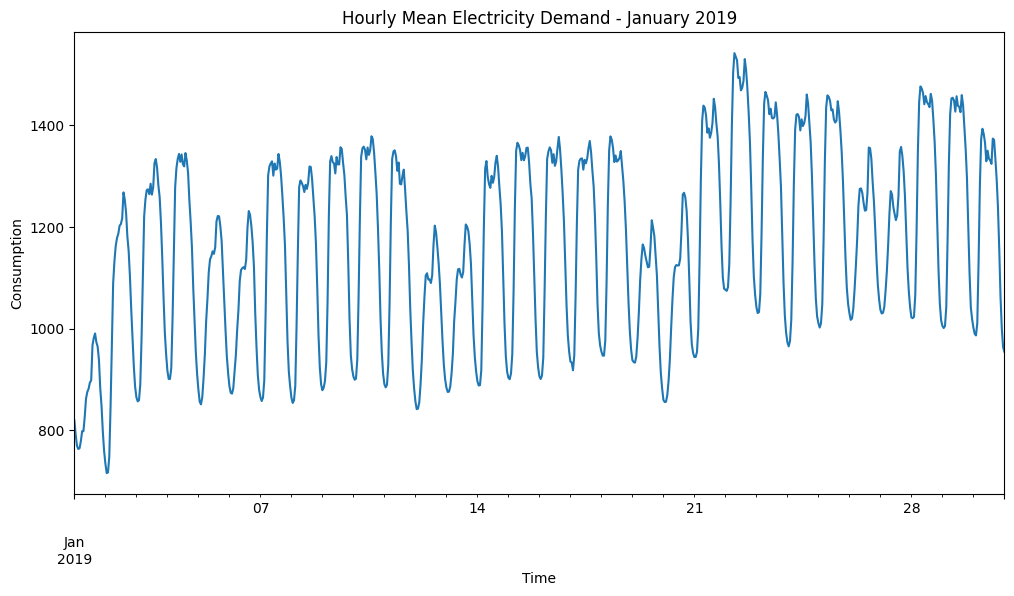

In [137]:
# Lige før EstLink 2 nedbrud 25. dec 2024
response1 = requests.get(
    "https://dashboard.elering.ee/api/system",
    params={
        "start": "2019-01-01T00:00:00.000Z",
        "end":   "2019-01-31T00:00:00.000Z"
    }
)

data1 = response1.json()

df1 = pd.DataFrame(data1["data"])
df1["timestamp"] = pd.to_datetime(df1["timestamp"], unit="s")
df1.set_index("timestamp", inplace=True)

demand_jan2019 = df1["consumption"].dropna()

# Cleaning 0-values around 11:40-11:45 on Jan 3, 2019
demand_jan2019.loc["2019-01-03 11:40:00"] = demand_jan2019.loc["2019-01-03 11:35:00"]
demand_jan2019.loc["2019-01-03 11:45:00"] = demand_jan2019.loc["2019-01-03 11:50:00"]

# Aggregate to hourly mean
demand_jan2019_hourly = demand_jan2019.resample("h").mean().dropna()

# Plot
demand_jan2019_hourly.plot(
    figsize=(12, 6),
    title="Hourly Mean Electricity Demand - January 2019",
    xlabel="Time",
    ylabel="Consumption"
)

<AxesSubplot: title={'center': 'Hourly Mean Electricity Demand - January 2020'}, xlabel='Time', ylabel='Consumption'>

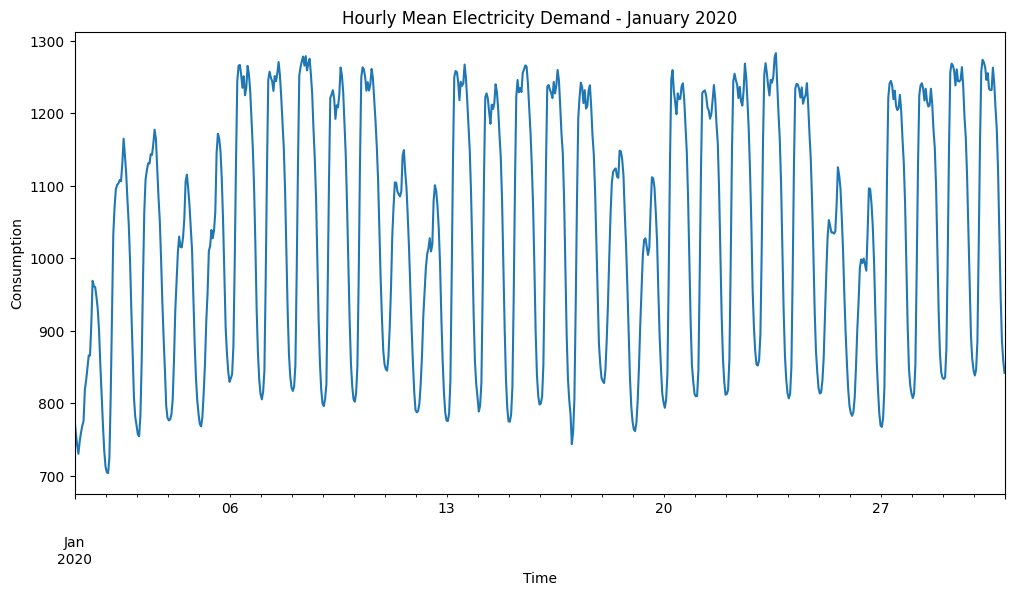

In [138]:
# Lige før EstLink 2 nedbrud 25. dec 2024
response2 = requests.get(
    "https://dashboard.elering.ee/api/system",
    params={
        "start": "2020-01-01T00:00:00.000Z",
        "end":   "2020-01-31T00:00:00.000Z"
    }
)

data2 = response2.json()

df2 = pd.DataFrame(data2["data"])
df2["timestamp"] = pd.to_datetime(df2["timestamp"], unit="s")
df2.set_index("timestamp", inplace=True)

demand_jan2020 = df2["consumption"].dropna()

# Aggregate to hourly mean
demand_jan2020_hourly = demand_jan2020.resample("h").mean().dropna()

# Plot
demand_jan2020_hourly.plot(
    figsize=(12, 6),
    title="Hourly Mean Electricity Demand - January 2020",
    xlabel="Time",
    ylabel="Consumption"
)

<AxesSubplot: title={'center': 'Hourly Mean Electricity Demand - January 2021'}, xlabel='Time', ylabel='Consumption'>

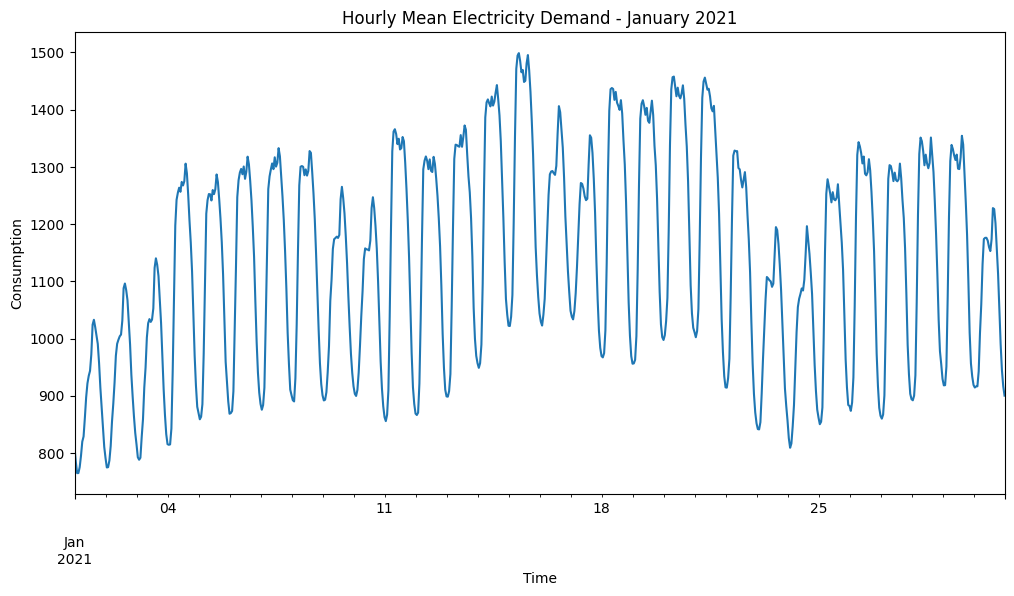

In [139]:
# Lige før EstLink 2 nedbrud 25. dec 2024
response3 = requests.get(
    "https://dashboard.elering.ee/api/system",
    params={
        "start": "2021-01-01T00:00:00.000Z",
        "end":   "2021-01-31T00:00:00.000Z"
    }
)

data3 = response3.json()

df3 = pd.DataFrame(data3["data"])
df3["timestamp"] = pd.to_datetime(df3["timestamp"], unit="s")
df3.set_index("timestamp", inplace=True)

demand_jan2021 = df3["consumption"].dropna()

# Aggregate to hourly mean
demand_jan2021_hourly = demand_jan2021.resample("h").mean().dropna()

# Plot
demand_jan2021_hourly.plot(
    figsize=(12, 6),
    title="Hourly Mean Electricity Demand - January 2021",
    xlabel="Time",
    ylabel="Consumption"
)

<AxesSubplot: title={'center': 'Hourly Mean Electricity Demand - January 2022'}, xlabel='Time', ylabel='Consumption'>

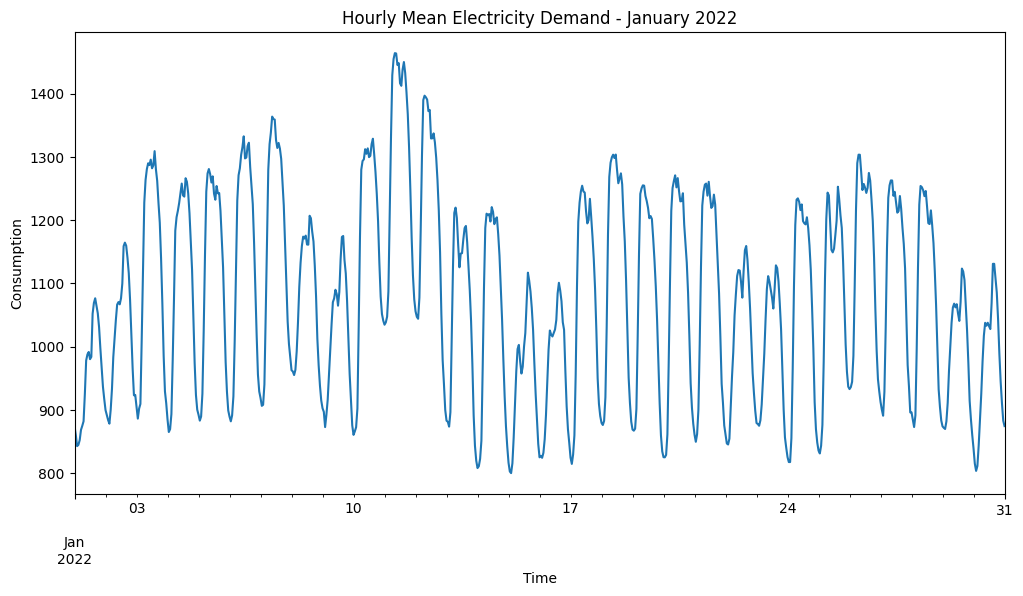

In [140]:
# Lige før EstLink 2 nedbrud 25. dec 2024
response4 = requests.get(
    "https://dashboard.elering.ee/api/system",
    params={
        "start": "2022-01-01T00:00:00.000Z",
        "end":   "2022-01-31T00:00:00.000Z"
    }
)

data4 = response4.json()

df4 = pd.DataFrame(data4["data"])
df4["timestamp"] = pd.to_datetime(df4["timestamp"], unit="s")
df4.set_index("timestamp", inplace=True)

demand_jan2022 = df4["consumption"].dropna()

# Aggregate to hourly mean
demand_jan2022_hourly = demand_jan2022.resample("h").mean().dropna()

# Plot
demand_jan2022_hourly.plot(
    figsize=(12, 6),
    title="Hourly Mean Electricity Demand - January 2022",
    xlabel="Time",
    ylabel="Consumption"
)

<AxesSubplot: title={'center': 'Hourly Mean Electricity Demand - January 2023'}, xlabel='Time', ylabel='Consumption'>

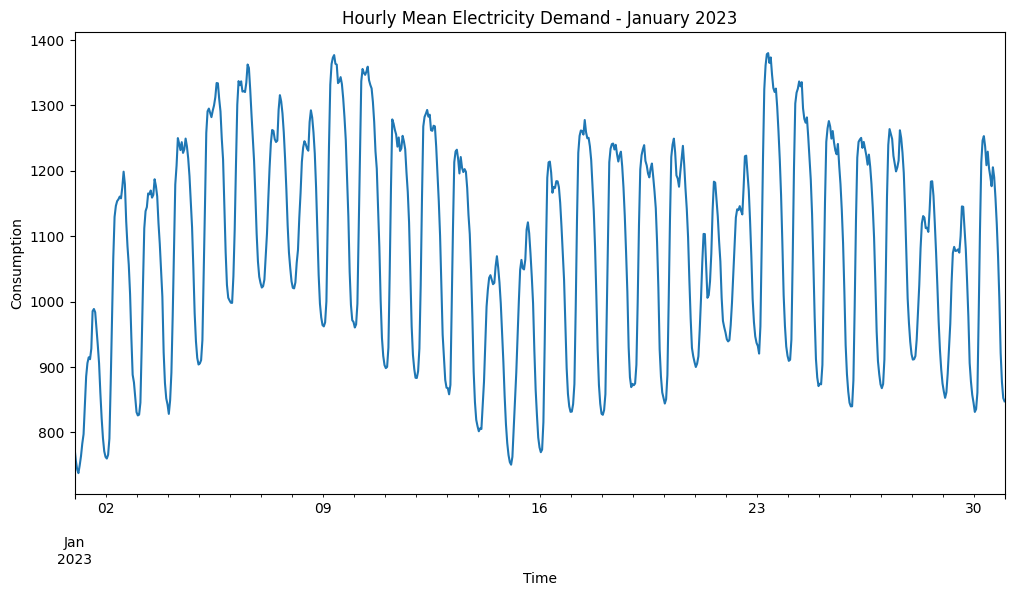

In [141]:
response5 = requests.get(
    "https://dashboard.elering.ee/api/system",
    params={
        "start": "2023-01-01T00:00:00.000Z",
        "end":   "2023-01-31T00:00:00.000Z"
    }
)

data5 = response5.json()

df5 = pd.DataFrame(data5["data"])
df5["timestamp"] = pd.to_datetime(df5["timestamp"], unit="s")
df5.set_index("timestamp", inplace=True)

demand_jan2023 = df5["consumption"].dropna()

# Aggregate to hourly mean
demand_jan2023_hourly = demand_jan2023.resample("h").mean().dropna()

# Plot
demand_jan2023_hourly.plot(
    figsize=(12, 6),
    title="Hourly Mean Electricity Demand - January 2023",
    xlabel="Time",
    ylabel="Consumption"
)

<AxesSubplot: title={'center': 'Hourly Mean Electricity Demand - January 2024'}, xlabel='Time', ylabel='Consumption'>

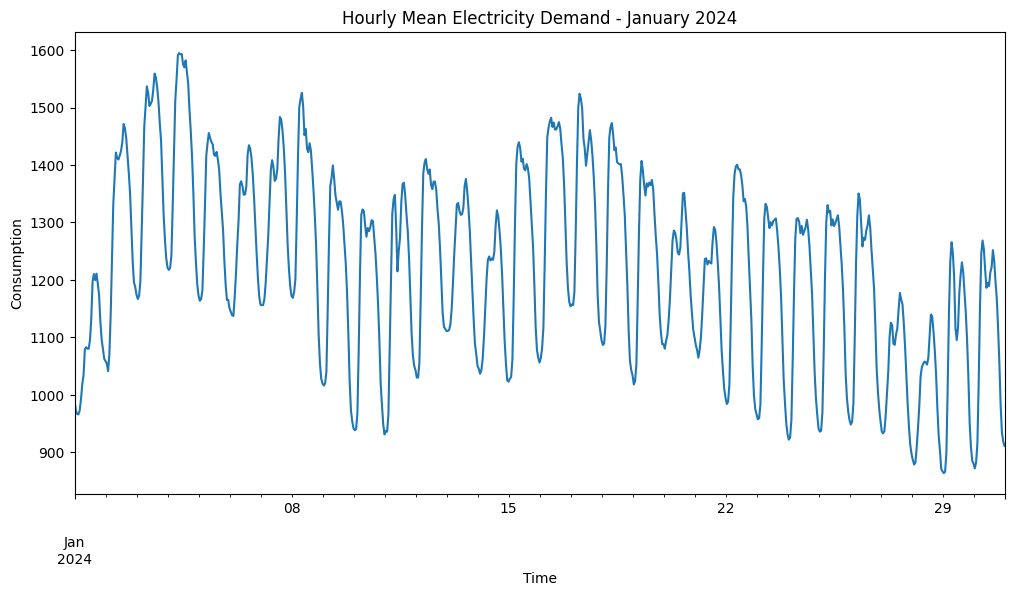

In [142]:
response6 = requests.get(
    "https://dashboard.elering.ee/api/system",
    params={
        "start": "2024-01-01T00:00:00.000Z",
        "end":   "2024-01-31T00:00:00.000Z"
    }
)

data6 = response6.json()

df6 = pd.DataFrame(data6["data"])
df6["timestamp"] = pd.to_datetime(df6["timestamp"], unit="s")
df6.set_index("timestamp", inplace=True)

demand_jan2024 = df6["consumption"].dropna()

# Aggregate to hourly mean
demand_jan2024_hourly = demand_jan2024.resample("h").mean().dropna()

# Plot
demand_jan2024_hourly.plot(
    figsize=(12, 6),
    title="Hourly Mean Electricity Demand - January 2024",
    xlabel="Time",
    ylabel="Consumption"
)

<AxesSubplot: title={'center': 'Hourly Mean Electricity Demand - January 2025'}, xlabel='Time', ylabel='Consumption'>

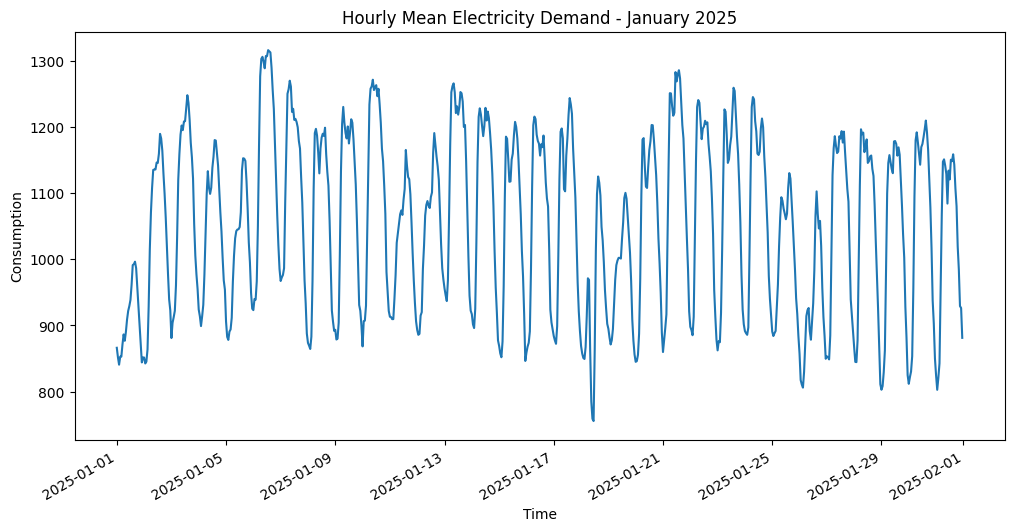

In [231]:
response7 = requests.get(
    "https://dashboard.elering.ee/api/system",
    params={
        "start": "2025-01-01T00:00:00.000Z",
        "end":   "2025-01-31T23:59:59.000Z"
    }
)

data7 = response7.json()

df7 = pd.DataFrame(data7["data"])
df7["timestamp"] = pd.to_datetime(df7["timestamp"], unit="s")
df7.set_index("timestamp", inplace=True)

demand_jan2025 = df7["consumption"].dropna()

# Aggregate to hourly mean
demand_jan2025_hourly = demand_jan2025.resample("h").mean().dropna()

# Plot
demand_jan2025_hourly.plot(
    figsize=(12, 6),
    title="Hourly Mean Electricity Demand - January 2025",
    xlabel="Time",
    ylabel="Consumption"
)

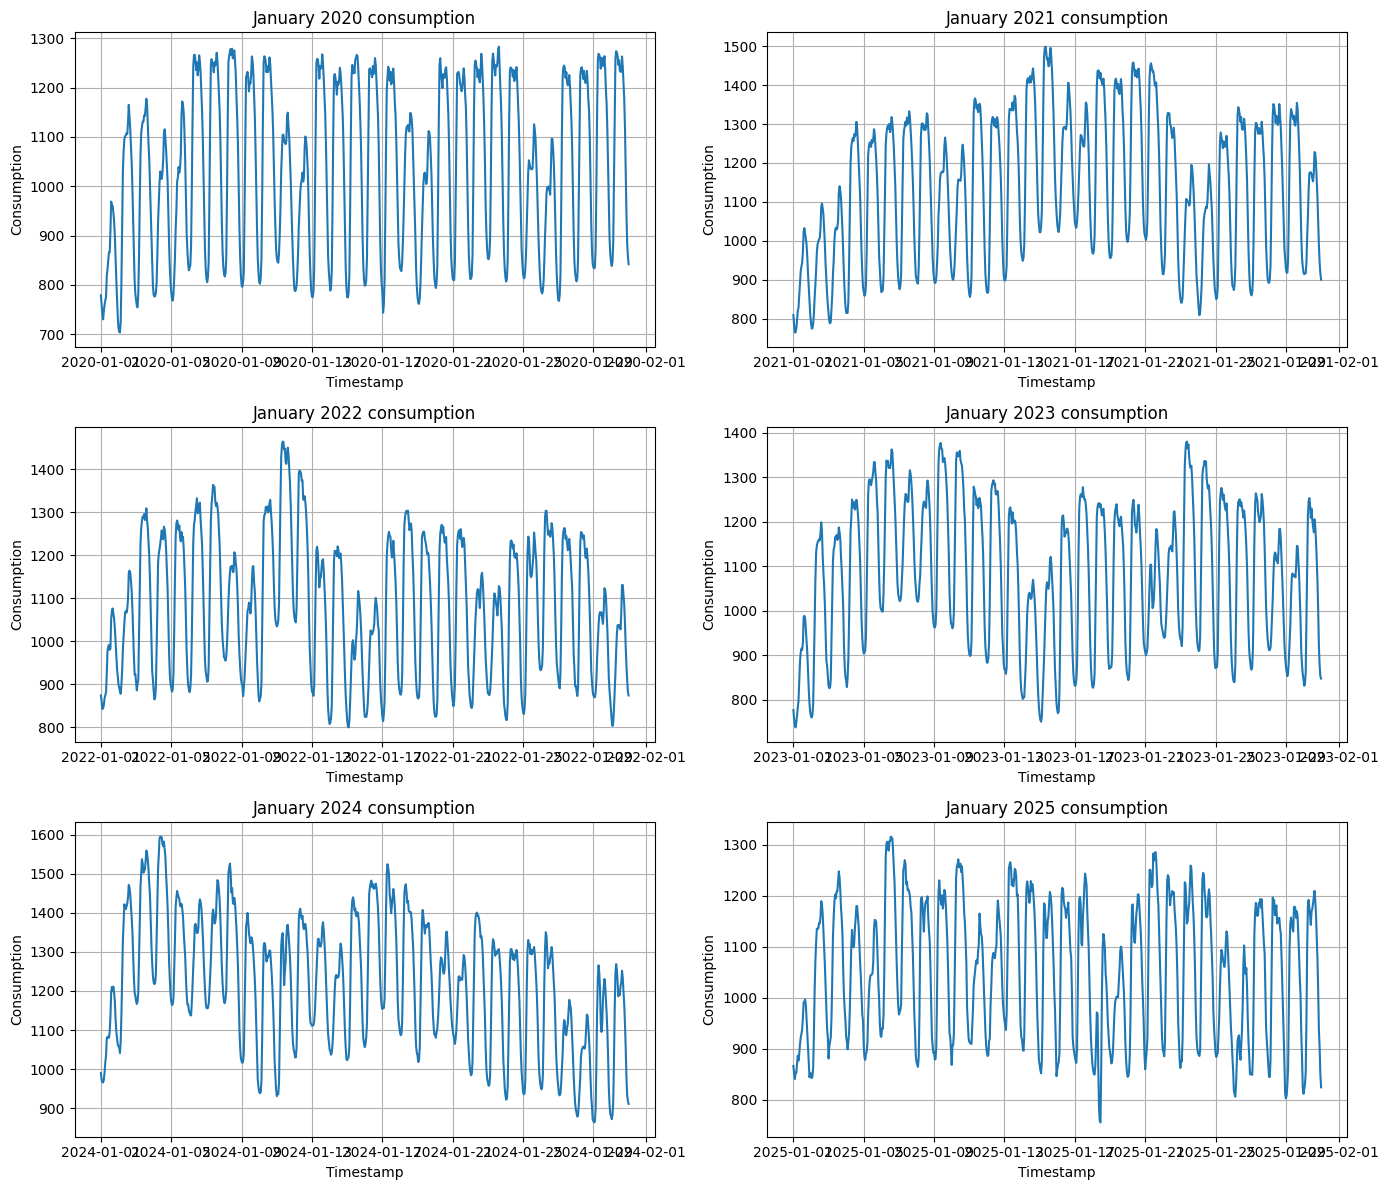

In [144]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=False, sharey=False)

years = [2020, 2021, 2022, 2023, 2024, 2025]
series_list = [
    demand_jan2020_hourly,
    demand_jan2021_hourly,
    demand_jan2022_hourly,
    demand_jan2023_hourly,
    demand_jan2024_hourly,
    demand_jan2025_hourly,
]

for ax, year, series in zip(axes.flatten(), years, series_list):
    ax.plot(series.index, series.values)
    ax.set_title(f"January {year} consumption")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Consumption")
    ax.grid(True)

plt.tight_layout()
plt.show()

In [145]:
def plot_acf_pacf(series, title, lags=168):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    plot_acf(series.dropna(), lags=lags, ax=axes[0])
    axes[0].set_title(f"ACF: {title}")
    axes[0].grid(True)

    plot_pacf(series.dropna(), lags=lags, ax=axes[1], method="ywm")
    axes[1].set_title(f"PACF: {title}")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

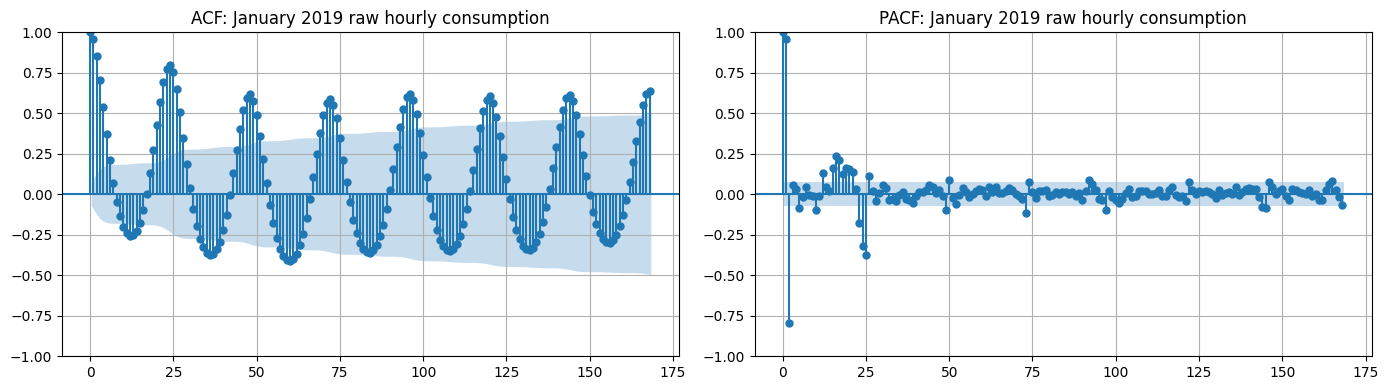

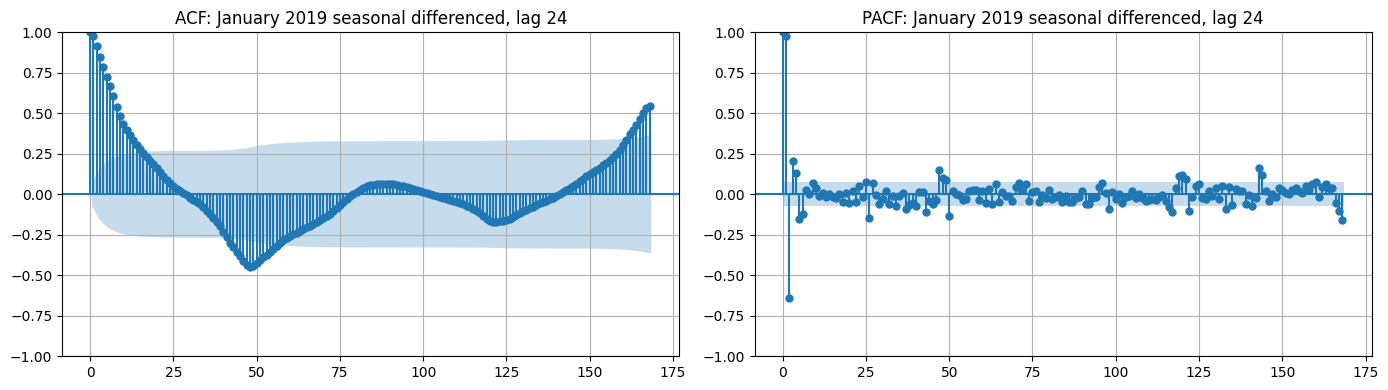

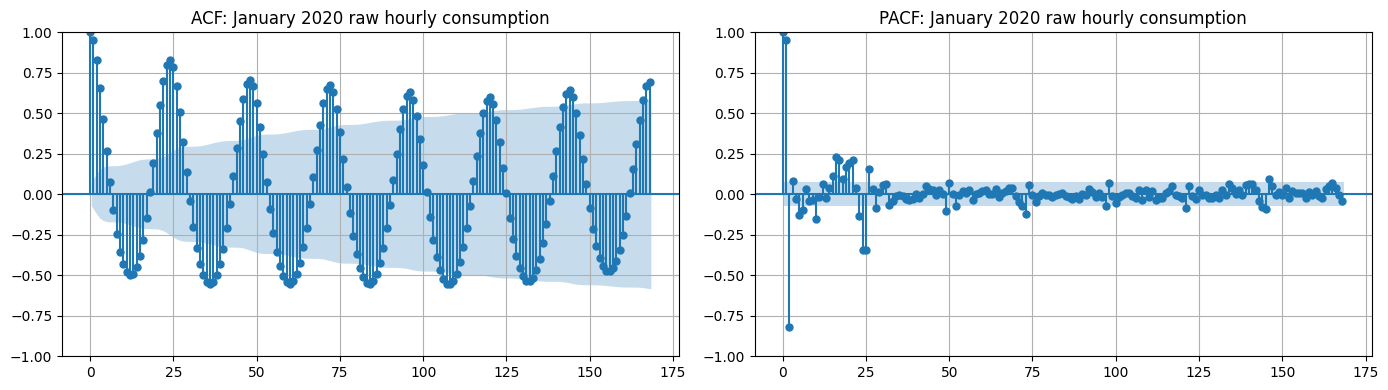

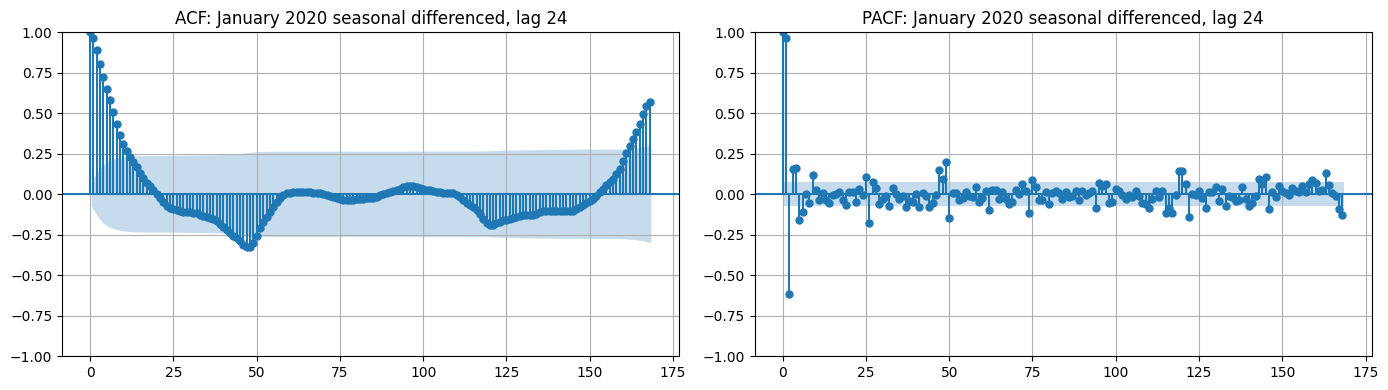

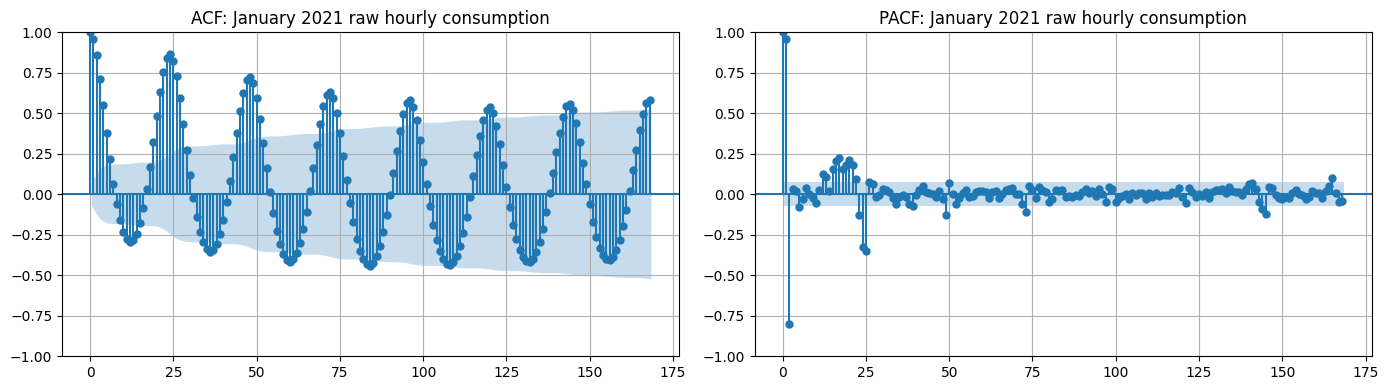

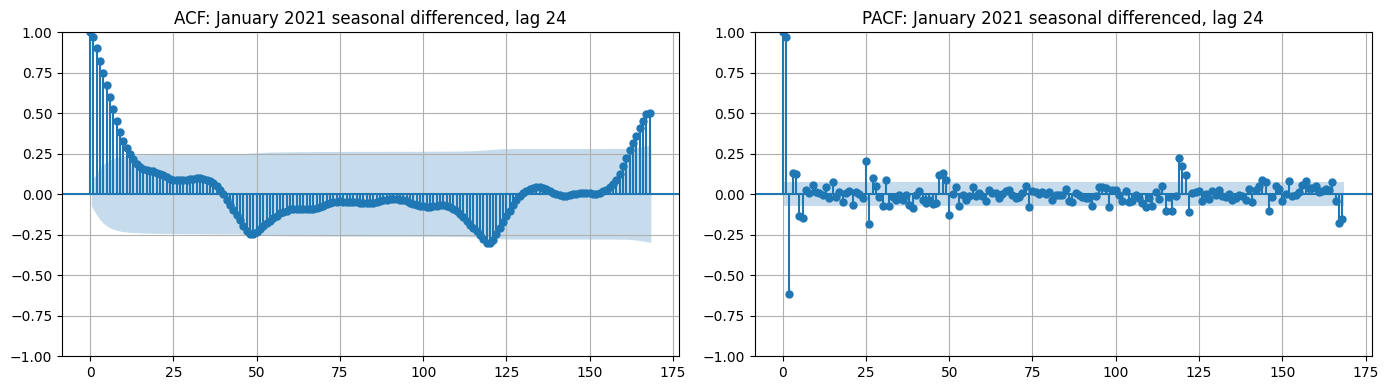

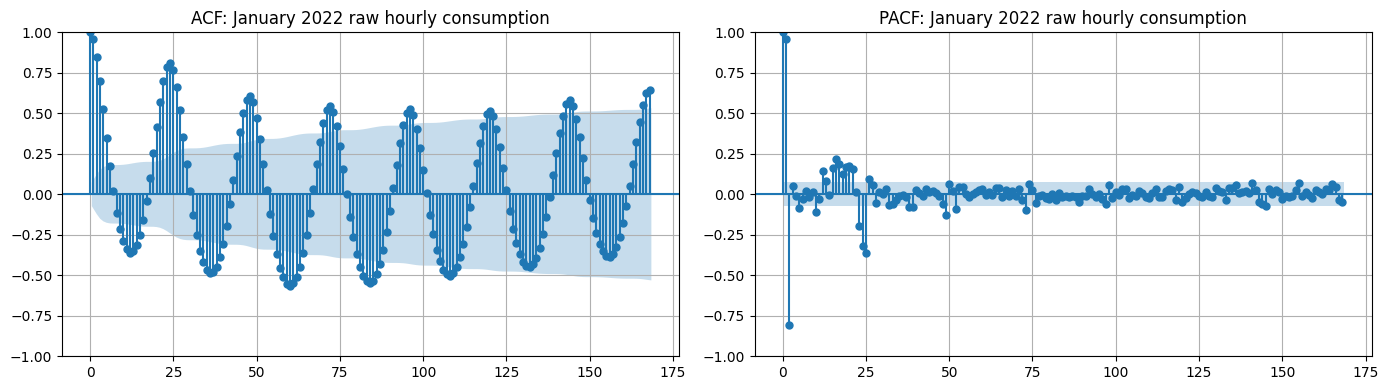

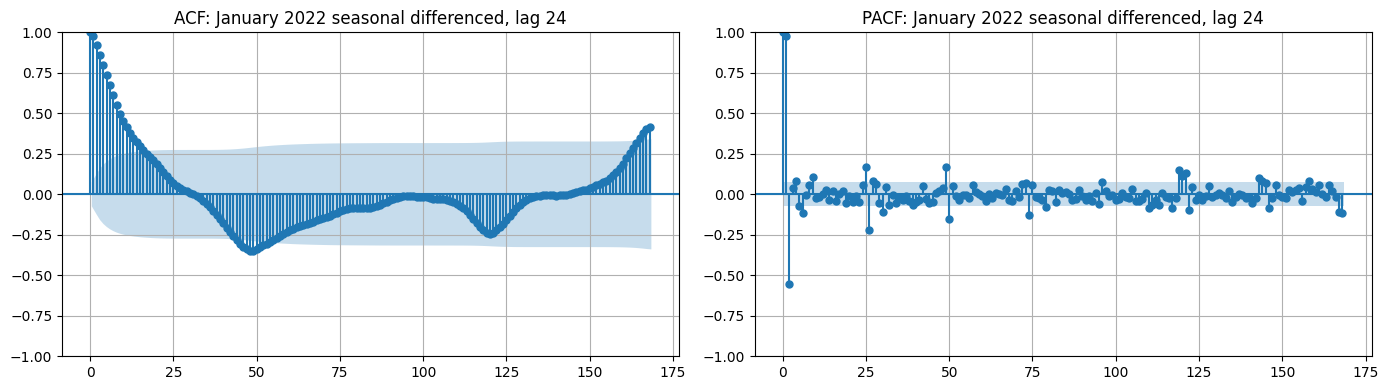

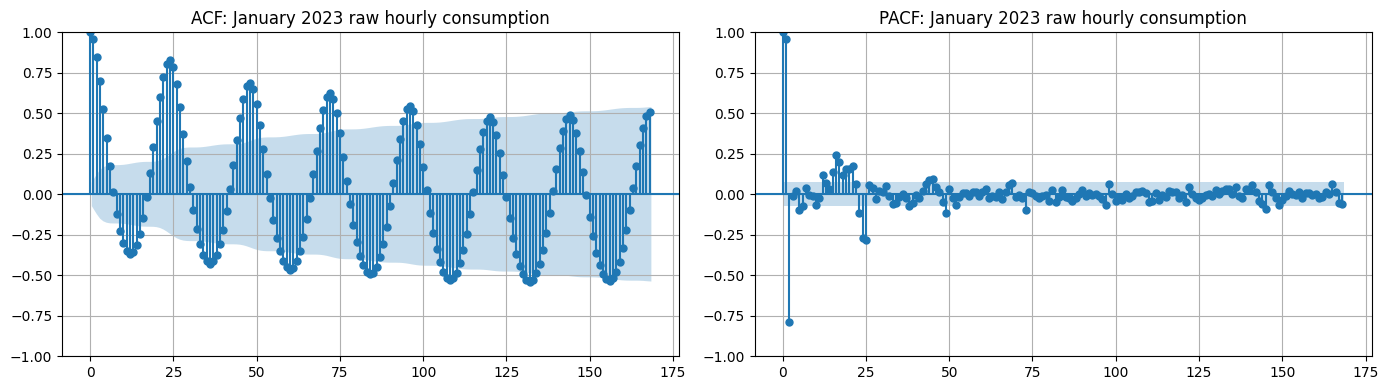

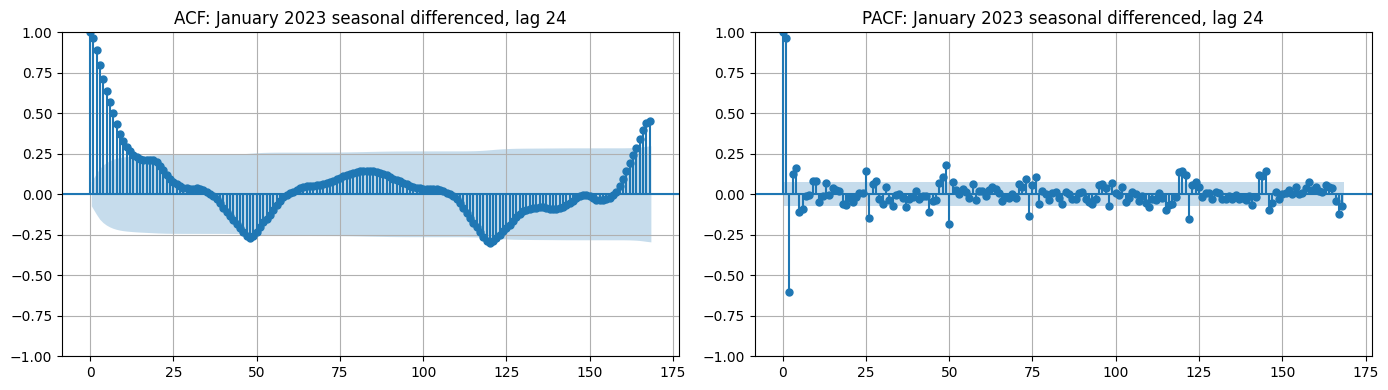

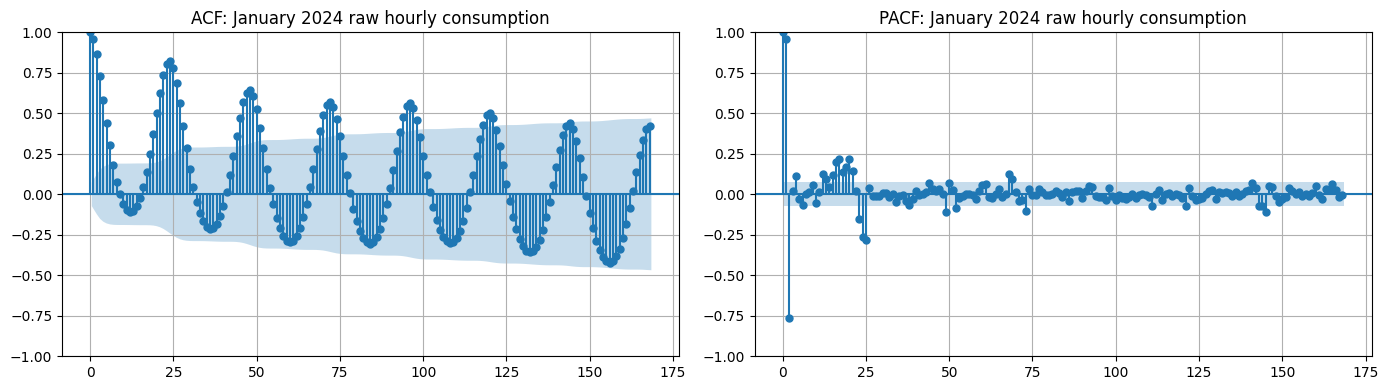

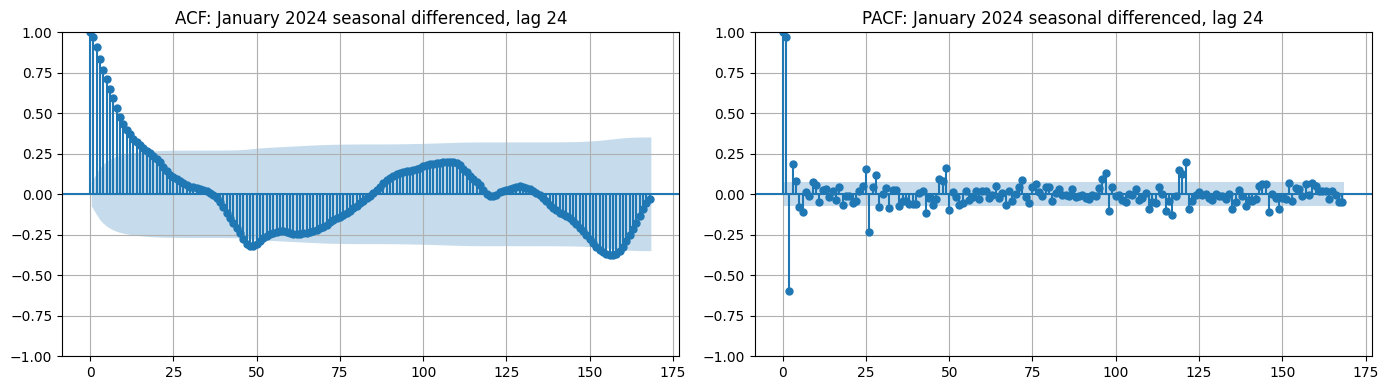

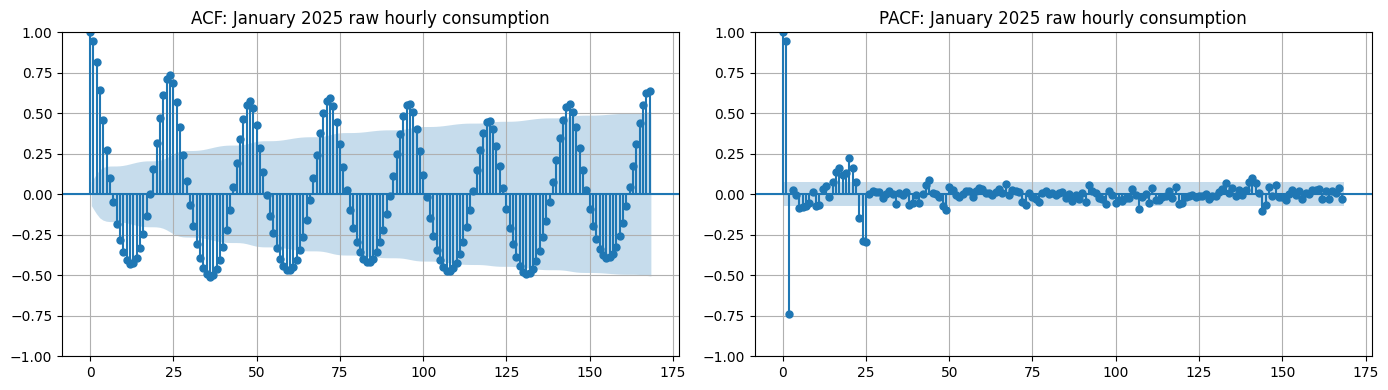

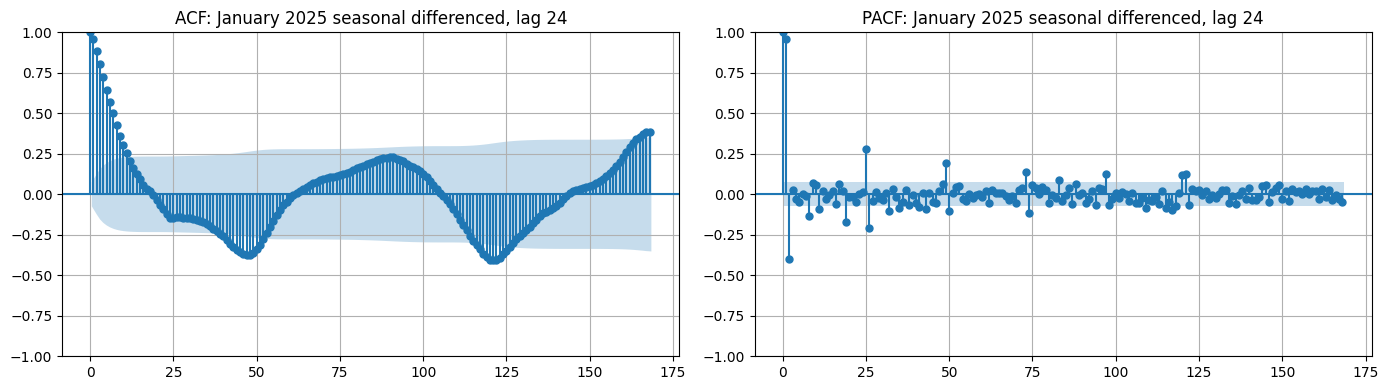

In [146]:
demand_series = {
    2019: demand_jan2019_hourly,
    2020: demand_jan2020_hourly,
    2021: demand_jan2021_hourly,
    2022: demand_jan2022_hourly,
    2023: demand_jan2023_hourly,
    2024: demand_jan2024_hourly,
    2025: demand_jan2025_hourly,
}

for year, y in demand_series.items():
    plot_acf_pacf(y, f"January {year} raw hourly consumption", lags=168)

    y_sdiff = y.diff(24)
    plot_acf_pacf(y_sdiff, f"January {year} seasonal differenced, lag 24", lags=168)

In [149]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
import pandas as pd
import numpy as np
import warnings
from IPython.display import display

# -----------------------------
# 1. Collect all yearly demand series
# -----------------------------
demand_series = {
    2019: demand_jan2019_hourly,
    2020: demand_jan2020_hourly,
    2021: demand_jan2021_hourly,
    2022: demand_jan2022_hourly,
    2023: demand_jan2023_hourly,
    2024: demand_jan2024_hourly,
    2025: demand_jan2025_hourly,
}

# -----------------------------
# 2. Define candidate SARIMA models
# -----------------------------
candidate_models = [
    ((2, 0, 2), (1, 1, 1, 24)),
    ((2, 0, 2), (1, 0, 1, 24)),
    ((3, 0, 2), (1, 1, 1, 24)),
]

# Choose ranking metric
rank_metric = "AIC"   # use "BIC" if you prefer simpler models

# -----------------------------
# 3. Fit models year by year
# -----------------------------
all_results = []

for year, y in demand_series.items():

    y = y.dropna()

    yearly_results = []

    for model_id, (order, seasonal_order) in enumerate(candidate_models):

        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")

                model = SARIMAX(
                    y,
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )

                fit = model.fit(disp=False)

            lb = acorr_ljungbox(
                fit.resid.dropna(),
                lags=[24],
                return_df=True
            )

            yearly_results.append({
                "year": year,
                "model_id": model_id,
                "order": order,
                "seasonal_order": seasonal_order,
                "AIC": fit.aic,
                "BIC": fit.bic,
                "Ljung-Box p-value lag 24": lb.loc[24, "lb_pvalue"],
                "converged": fit.mle_retvals.get("converged", None)
            })

        except Exception as e:
            yearly_results.append({
                "year": year,
                "model_id": model_id,
                "order": order,
                "seasonal_order": seasonal_order,
                "AIC": np.nan,
                "BIC": np.nan,
                "Ljung-Box p-value lag 24": np.nan,
                "converged": False,
                "error": str(e)
            })

    yearly_table = pd.DataFrame(yearly_results)

    # Sort by chosen ranking metric
    yearly_table = yearly_table.sort_values(rank_metric, ascending=True).reset_index(drop=True)

    # Score: best = 5, second = 4, ..., fifth = 1
    yearly_table["score"] = 0
    yearly_table.loc[:4, "score"] = list(range(3, 0, -1))

    print(f"\nModel comparison for January {year}, ranked by {rank_metric}")
    display(yearly_table)

    all_results.append(yearly_table)

# -----------------------------
# 4. Combine all yearly results
# -----------------------------
all_results_df = pd.concat(all_results, ignore_index=True)

# -----------------------------
# 5. Total score across all years
# -----------------------------
score_summary = (
    all_results_df
    .groupby(["order", "seasonal_order"], as_index=False)
    .agg(
        total_score=("score", "sum"),
        mean_score=("score", "mean"),
        mean_AIC=("AIC", "mean"),
        mean_BIC=("BIC", "mean"),
        median_AIC=("AIC", "median"),
        median_BIC=("BIC", "median"),
        first_places=("score", lambda x: (x == 3).sum()),
        years_tested=("score", "count")
    )
    .sort_values(
        ["total_score", "first_places", "mean_AIC"],
        ascending=[False, False, True]
    )
    .reset_index(drop=True)
)

print("\nOverall model score across all years")
display(score_summary)

# -----------------------------
# 6. Extract the overall best model
# -----------------------------
best_overall_model = score_summary.iloc[0]

print("Best overall model:")
print(f"order = {best_overall_model['order']}")
print(f"seasonal_order = {best_overall_model['seasonal_order']}")
print(f"total_score = {best_overall_model['total_score']}")
print(f"first_places = {best_overall_model['first_places']}")
print(f"mean_AIC = {best_overall_model['mean_AIC']:.2f}")
print(f"mean_BIC = {best_overall_model['mean_BIC']:.2f}")


Model comparison for January 2019, ranked by AIC


,year,model_id,order,seasonal_order,AIC,BIC,Ljung-Box p-value lag 24,converged,score
0,2019,0,"(2, 0, 2)","(1, 1, 1, 24)",5440.267258,5471.818202,4.855649e-42,True,3
1,2019,2,"(3, 0, 2)","(1, 1, 1, 24)",5487.813201,5523.871423,4.178833e-20,True,2
2,2019,1,"(2, 0, 2)","(1, 0, 1, 24)",5712.022121,5743.819424,2.662850e-21,True,1



Model comparison for January 2020, ranked by AIC


,year,model_id,order,seasonal_order,AIC,BIC,Ljung-Box p-value lag 24,converged,score
0,2020,2,"(3, 0, 2)","(1, 1, 1, 24)",5435.537073,5471.595294,1.006745e-35,True,3
1,2020,0,"(2, 0, 2)","(1, 1, 1, 24)",5435.958558,5467.509502,1.544610e-68,True,2
2,2020,1,"(2, 0, 2)","(1, 0, 1, 24)",5700.271699,5732.069002,4.471613e-20,True,1



Model comparison for January 2021, ranked by AIC


...


Model comparison for January 2025, ranked by AIC


,year,model_id,order,seasonal_order,AIC,BIC,Ljung-Box p-value lag 24,converged,score
0,2025,0,"(2, 0, 2)","(1, 1, 1, 24)",5910.819015,5942.359504,6.405355e-48,True,3
1,2025,2,"(3, 0, 2)","(1, 1, 1, 24)",5957.921476,5993.967749,1.339614e-15,False,2
2,2025,1,"(2, 0, 2)","(1, 0, 1, 24)",6130.676057,6162.463267,3.656687e-19,True,1



Overall model score across all years


,order,seasonal_order,total_score,mean_score,mean_AIC,mean_BIC,median_AIC,median_BIC,first_places,years_tested
0,"(2, 0, 2)","(1, 1, 1, 24)",18,2.571429,5497.983571,5529.533022,5435.958558,5467.509502,4,7
1,"(3, 0, 2)","(1, 1, 1, 24)",17,2.428571,5510.083184,5546.139699,5435.537073,5471.595294,3,7
2,"(2, 0, 2)","(1, 0, 1, 24)",7,1.000000,5763.776281,5795.572143,5708.896489,5740.693792,0,7


Best overall model:
order = (2, 0, 2)
seasonal_order = (1, 1, 1, 24)
total_score = 18
first_places = 4
mean_AIC = 5497.98
mean_BIC = 5529.53


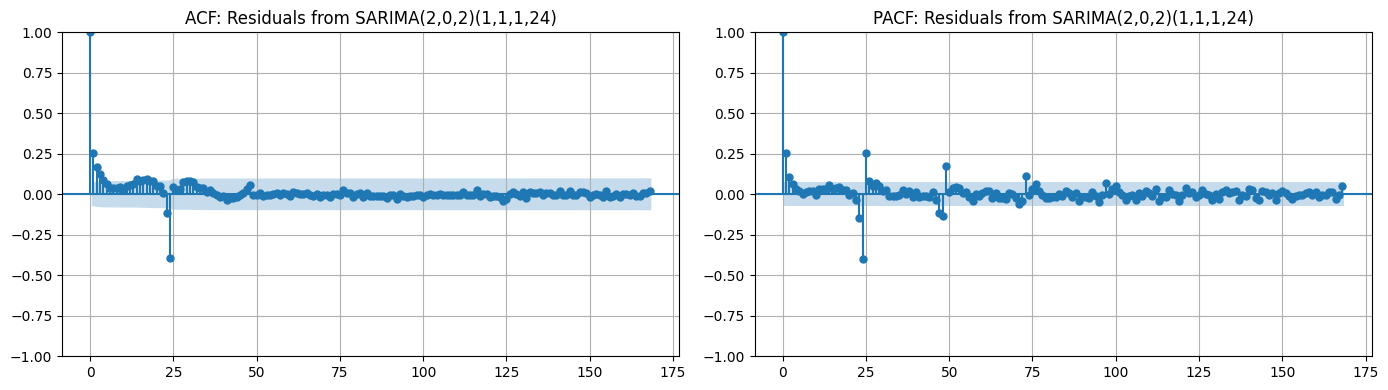

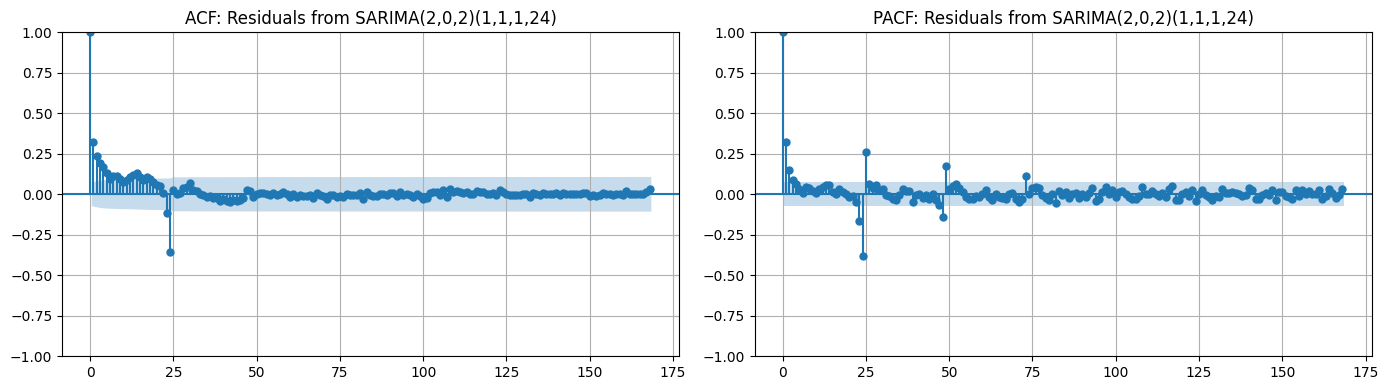

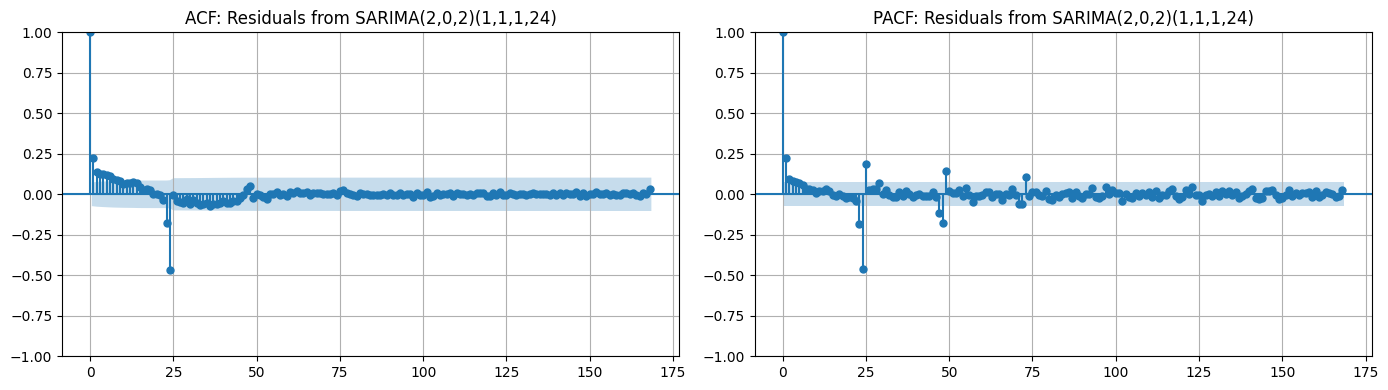

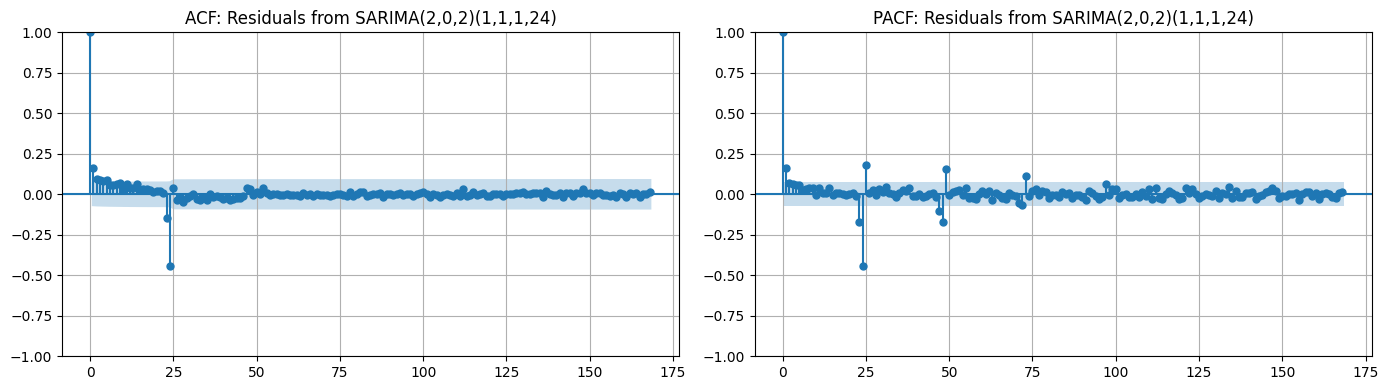

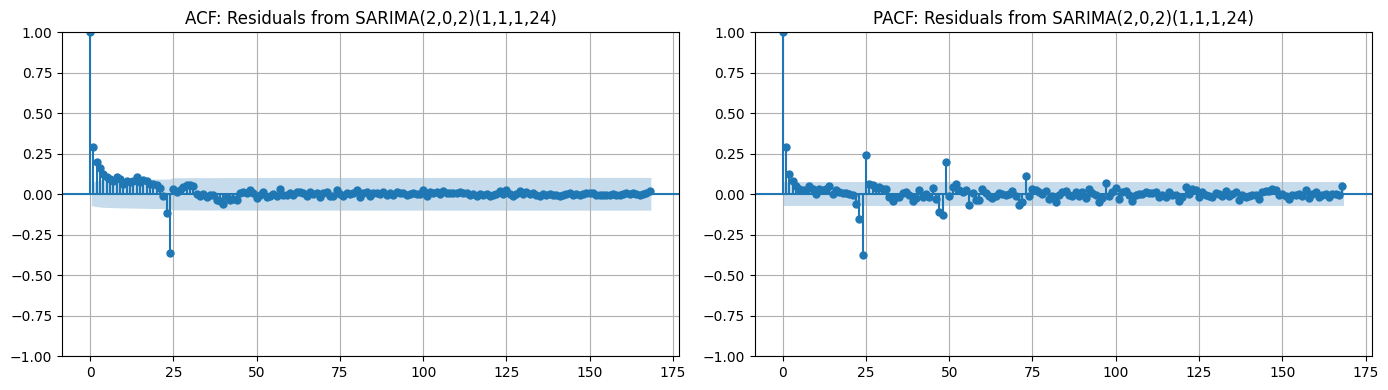

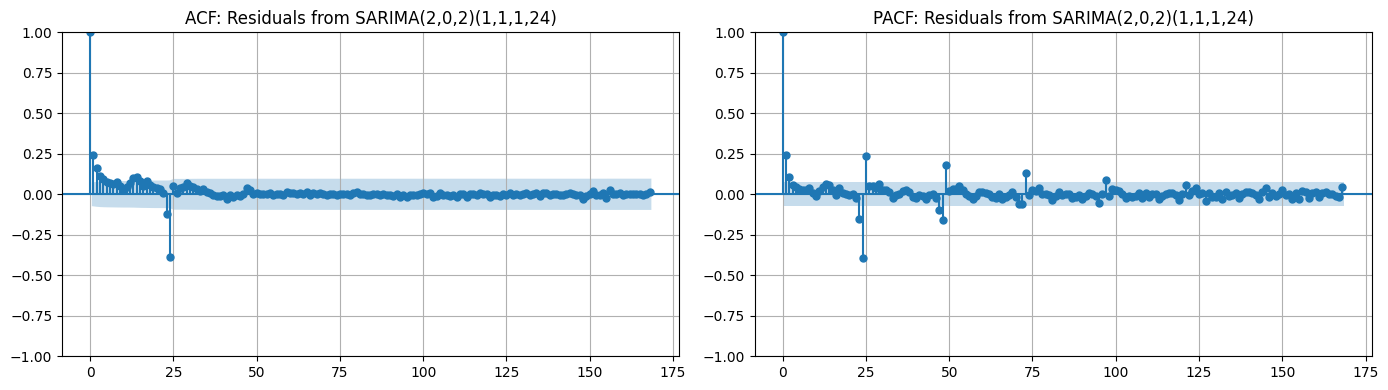

/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


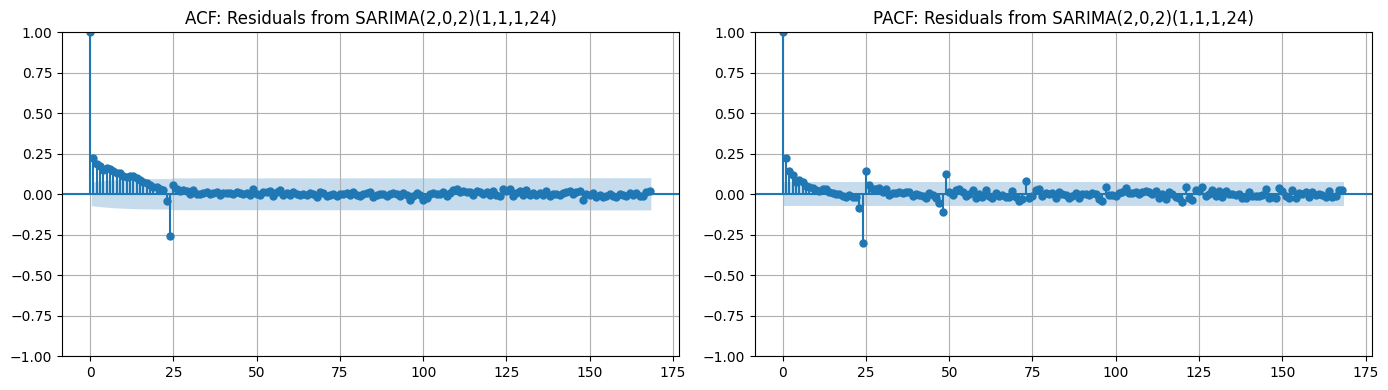

In [ ]:
for year, y in demand_series.items():
    best_model = SARIMAX(
        y,
        order=(2, 0, 2),
        seasonal_order=(1, 1, 1, 24),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    best_fit = best_model.fit(disp=False)

    resid = best_fit.resid.dropna()

    plot_acf_pacf(
        resid,
        "Residuals from SARIMA(2,0,2)(1,1,1,24)",
        lags=168
    )

In [182]:
demand_jan2019_hourly

timestamp
2019-01-01 00:00:00     819.438875
2019-01-01 01:00:00     791.056508
2019-01-01 02:00:00     769.771533
2019-01-01 03:00:00     763.496150
2019-01-01 04:00:00     764.953825
                          ...     
2019-01-30 20:00:00    1156.709675
2019-01-30 21:00:00    1061.950033
2019-01-30 22:00:00     999.722333
2019-01-30 23:00:00     963.265075
2019-01-31 00:00:00     954.671200
Freq: h, Name: consumption, Length: 721, dtype: float64

In [183]:
model_2019 = SARIMAX(
    demand_jan2019_hourly,
    order=(2, 0, 2),
    seasonal_order=(1, 1, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)
fit_2019 = model_2019.fit(disp=False)

model_2020 = SARIMAX(
    demand_jan2020_hourly,
    order=(2, 0, 2),
    seasonal_order=(1, 1, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)
fit_2020 = model_2020.fit(disp=False)

model_2021 = SARIMAX(
    demand_jan2021_hourly,
    order=(2, 0, 2),
    seasonal_order=(1, 1, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)
fit_2021 = model_2021.fit(disp=False)

model_2022 = SARIMAX(
    demand_jan2022_hourly,
    exog=None,
    order=(2, 0, 2),
    seasonal_order=(1, 1, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)
fit_2022 = model_2022.fit(disp=False)

model_2023 = SARIMAX(
    demand_jan2023_hourly,
    exog=None,
    order=(2, 0, 2),
    seasonal_order=(1, 1, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)
fit_2023 = model_2023.fit(disp=False)

model_2024 = SARIMAX(
    demand_jan2024_hourly,
    exog=None,
    order=(2, 0, 2),
    seasonal_order=(1, 1, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)
fit_2024 = model_2024.fit(disp=False)

model_2025 = SARIMAX(
    demand_jan2025_hourly,
    exog=None,
    order=(2, 0, 2),
    seasonal_order=(1, 1, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)
fit_2025 = model_2025.fit(disp=False)


/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [221]:
final_ar_l1 = sum([fit_2019.params[0],fit_2020.params[0],fit_2021.params[0],fit_2022.params[0],fit_2023.params[0],fit_2024.params[0],fit_2025.params[0]])/7
final_ar_l2 = sum([fit_2019.params[1],fit_2020.params[1],fit_2021.params[1],fit_2022.params[1],fit_2023.params[1],fit_2024.params[1],fit_2025.params[1]])/7
final_ma_l1 = sum([fit_2019.params[2],fit_2020.params[2],fit_2021.params[2],fit_2022.params[2],fit_2023.params[2],fit_2024.params[2],fit_2025.params[2]])/7
final_ma_l2 = sum([fit_2019.params[3],fit_2020.params[3],fit_2021.params[3],fit_2022.params[3],fit_2023.params[3],fit_2024.params[3],fit_2025.params[3]])/7
final_ar_l24 = sum([fit_2019.params[4],fit_2020.params[4],fit_2021.params[4],fit_2022.params[4],fit_2023.params[4],fit_2024.params[4],fit_2025.params[4]])/7
final_ma_l24 = sum([fit_2019.params[5],fit_2020.params[5],fit_2021.params[5],fit_2022.params[5],fit_2023.params[5],fit_2024.params[5],fit_2025.params[5]])/7
final_sigma2 = sum([fit_2019.params[6],fit_2020.params[6],fit_2021.params[6],fit_2022.params[6],fit_2023.params[6],fit_2024.params[6],fit_2025.params[6]])/7

params = np.array([final_ar_l1, final_ar_l2, final_ma_l1, final_ma_l2, final_ar_l24, final_ma_l24, final_sigma2])


/var/folders/l8/vd4xpb9j38d8zj2r1xy2bgmr0000gn/T/ipykernel_34687/2233847752.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  final_ar_l1 = sum([fit_2019.params[0],fit_2020.params[0],fit_2021.params[0],fit_2022.params[0],fit_2023.params[0],fit_2024.params[0],fit_2025.params[0]])/7
/var/folders/l8/vd4xpb9j38d8zj2r1xy2bgmr0000gn/T/ipykernel_34687/2233847752.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  final_ar_l2 = sum([fit_2019.params[1],fit_2020.params[1],fit_2021.params[1],fit_2022.params[1],fit_2023.params[1],fit_2024.params[1],fit_2025.params[1]])/7
/var/folders/l8/vd4xpb9j38d8zj2r1xy2bgmr0000gn/T/ipykern

In [ ]:
y_train = demand[demand.index.month == 1]

In [222]:
np.random.seed(123)

# -----------------------------
# Settings
# -----------------------------
n_hours = 31 * 24       # January
n_series = 5

simulated = model.simulate(
    params=params,
    nsimulations=n_hours,
    repetitions=n_series,
    anchor="end",
    random_state=123
)

simulated = np.asarray(simulated)

# Convert to DataFrame
sim_df = pd.DataFrame(
    simulated,
    columns=[f"Series {i+1}" for i in range(n_series)]
)

IndexError: index 7 is out of bounds for axis 0 with size 7

In [ ]:
# -----------------------------
# Monte Carlo settings
# -----------------------------
n_sims = 1000
n_hours = len(X_january_2026)   # 31 * 24 = 744 for January
seed = 123

# -----------------------------
# Simulate demand paths
# -----------------------------
simulated_paths = fit_final.simulate(
    nsimulations=n_hours,
    repetitions=n_sims,
    anchor="end",
    exog=X_january_2026,        # remove this line if pure SARIMA
    random_state=seed
)

# Convert to DataFrame
simulated_paths = pd.DataFrame(
    np.asarray(simulated_paths),
    index=X_january_2026.index
)

# Rename columns
simulated_paths.columns = [f"sim_{i+1}" for i in range(n_sims)]

In [195]:
import numpy as np
import pandas as pd

def simulate_fixed_sarima(fit, future_index, n_sims=1000, seed=123):
    """
    Monte Carlo simulation using fixed fitted SARIMA coefficients.
    Only the future shocks are random.
    """
    rng = np.random.default_rng(seed)
    steps = len(future_index)

    sims = []

    for i in range(n_sims):
        sim = fit.simulate(
            nsimulations=steps,
            anchor="end",
            random_state=rng
        )

        sim = pd.Series(np.asarray(sim).squeeze(), index=future_index, name=f"sim_{i}")
        sims.append(sim)

    return pd.concat(sims, axis=1)

future_index = pd.date_range(
    "2026-01-01 00:00:00",
    periods=31 * 24,
    freq="h"
)

mc_fixed = simulate_fixed_sarima(
    fit=fit_2025,              # or preferably a model fitted on all relevant historical data
    future_index=future_index,
    n_sims=1000,
    seed=123
)

/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/homebrew/lib/pyt

In [ ]:
fit_final = SARIMAX(
    y_train,                      # remove if pure SARIMA
    order=(2, 0, 2),
    seasonal_order=(1, 1, 1, 24),
    enforce_stationarity=True,
    enforce_invertibility=True
).fit()

In [194]:
params_all = [
    fit_2019.params, fit_2020.params, fit_2021.params,
    fit_2022.params, fit_2023.params, fit_2024.params
]

bse_all = [
    fit_2019.bse, fit_2020.bse, fit_2021.bse,
    fit_2022.bse, fit_2023.bse, fit_2024.bse
]

param_names = params_all[0].index.tolist()

# Convert to matrices
P = np.vstack([p.values for p in params_all])      # shape (6, k)
B = np.vstack([b.values for b in bse_all])         # shape (6, k)

# 1. Mean of parameters across years
mu = P.mean(axis=0)

# 2. Between-year covariance
Sigma_between = np.cov(P, rowvar=False)

# 3. Within-year covariance (diagonal)
Sigma_within = np.diag((B**2).mean(axis=0))

# 4. Total parameter uncertainty
Sigma_total = Sigma_between + Sigma_within


def draw_hierarchical_params():
    return np.random.multivariate_normal(mu, Sigma_total)

def simulate_january(demand_index, param_vector):
    p = dict(zip(param_names, param_vector))

    model = SARIMAX(
        endog=np.zeros(len(demand_index)),
        order=(2, 0, 2),
        seasonal_order=(1, 1, 1, 24),
        trend='n'
    )

    sim = model.simulate(
        params=p,
        nsimulations=len(demand_index)
    )

    sim.index = demand_index
    return sim

def run_monte_carlo(n_sims, demand_index):
    sims = []

    for _ in range(n_sims):
        theta_star = draw_hierarchical_params()
        sim_path = simulate_january(demand_index, theta_star)
        sims.append(sim_path)

    return pd.DataFrame(sims).T


date_index = pd.date_range("2024-01-01", "2024-02-01", freq="H")

mc_results = run_monte_carlo(1000, date_index)

print(mc_results.head())


/var/folders/l8/vd4xpb9j38d8zj2r1xy2bgmr0000gn/T/ipykernel_34687/2986925690.py:62: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  date_index = pd.date_range("2024-01-01", "2024-02-01", freq="H")


IndexError: index 6 is out of bounds for axis 0 with size 1

In [184]:
print(fit_2019.summary())
print(fit_2020.summary())
print(fit_2021.summary())
print(fit_2022.summary())
print(fit_2023.summary())
print(fit_2024.summary())
print(fit_2025.summary())

                                      SARIMAX Results                                       
Dep. Variable:                          consumption   No. Observations:                  721
Model:             SARIMAX(2, 0, 2)x(1, 1, [1], 24)   Log Likelihood               -2713.134
Date:                              Sat, 25 Apr 2026   AIC                           5440.267
Time:                                      14:41:34   BIC                           5471.818
Sample:                                  01-01-2019   HQIC                          5452.488
                                       - 01-31-2019                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.1193      0.063     17.874      0.000       0.997       1.242
ar.L2         -0.18

In [ ]:
def fetch_weather_from_openmeteo(lat, lon, start_date, end_date, location_name=""):
    """
    Fetch hourly historical weather from Open-Meteo (FREE, no authentication needed).
    
    Parameters:
        lat, lon: Location coordinates (WGS84)
        start_date, end_date: ISO format strings like '2019-01-01' or datetime objects
        location_name: Optional name for logging
    
    Returns:
        pandas DataFrame with temperature, humidity, wind speed, etc.
    """
    
    # Parse dates if strings
    if isinstance(start_date, str):
        start_date = datetime.datetime.fromisoformat(start_date)
    if isinstance(end_date, str):
        end_date = datetime.datetime.fromisoformat(end_date)
    
    # Convert to date strings for API
    start_str = start_date.strftime("%Y-%m-%d")
    end_str = end_date.strftime("%Y-%m-%d")
    
    # Open-Meteo archive API (free, no auth needed)
    ARCHIVE_URL = "https://archive-api.open-meteo.com/v1/archive"
    
    print(f"  Fetching {location_name} {start_str} to {end_str}...")
    
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_str,
        "end_date": end_str,
        "hourly": "temperature_2m,relative_humidity_2m,wind_speed_10m,pressure_msl",
        "temperature_unit": "celsius",
        "wind_speed_unit": "kmh",
        "timezone": "UTC"
    }
    
    try:
        r = requests.get(ARCHIVE_URL, params=params, timeout=60)
        r.raise_for_status()
        data = r.json()
        
        if "hourly" not in data:
            print(f"  ❌ Error: {data.get('reason', 'Unknown error')}")
            return pd.DataFrame()
        
        # Extract hourly data
        hourly_data = data["hourly"]
        
        # Create DataFrame
        df = pd.DataFrame({
            "timestamp": pd.to_datetime(hourly_data["time"]),
            "temperature": hourly_data["temperature_2m"],
            "humidity": hourly_data["relative_humidity_2m"],
            "wind_speed": hourly_data["wind_speed_10m"],
            "pressure": hourly_data["pressure_msl"]
        })
        
        df.set_index("timestamp", inplace=True)
        df = df[~df.index.duplicated(keep="first")]
        
        print(f"  ✅ Total: {len(df)} records from {df.index.min()} to {df.index.max()}")
        return df
        
    except Exception as e:
        print(f"  ❌ Error: {e}")
        return pd.DataFrame()

# Fetch data for Estonia (Tallinn center) for 2019-2025
print("Fetching historical weather data from Open-Meteo...\n")

df_weather_2019 = fetch_weather_from_openmeteo(
    lat=59.437,
    lon=24.753,
    start_date="2019-01-01",
    end_date="2019-12-31",
    location_name="Estonia 2019"
)

df_weather_2020 = fetch_weather_from_openmeteo(
    lat=59.437,
    lon=24.753,
    start_date="2020-01-01",
    end_date="2020-12-31",
    location_name="Estonia 2020"
)

df_weather_2021 = fetch_weather_from_openmeteo(
    lat=59.437,
    lon=24.753,
    start_date="2021-01-01",
    end_date="2021-12-31",
    location_name="Estonia 2021"
)

df_weather_2022 = fetch_weather_from_openmeteo(
    lat=59.437,
    lon=24.753,
    start_date="2022-01-01",
    end_date="2022-12-31",
    location_name="Estonia 2022"
)

df_weather_2023 = fetch_weather_from_openmeteo(
    lat=59.437,
    lon=24.753,
    start_date="2023-01-01",
    end_date="2023-12-31",
    location_name="Estonia 2023"
)

df_weather_2024 = fetch_weather_from_openmeteo(
    lat=59.437,
    lon=24.753,
    start_date="2024-01-01",
    end_date="2024-12-31",
    location_name="Estonia 2024"
)

df_weather_2025 = fetch_weather_from_openmeteo(
    lat=59.437,
    lon=24.753,
    start_date="2025-01-01",
    end_date="2025-04-24",
    location_name="Estonia 2025"
)

# Combine all years
df_weather_all = pd.concat([
    df_weather_2019,
    df_weather_2020,
    df_weather_2021,
    df_weather_2022,
    df_weather_2023,
    df_weather_2024,
    df_weather_2025
])

print(f"\nCombined dataset: {len(df_weather_all)} hourly records")
print(f"Date range: {df_weather_all.index.min()} to {df_weather_all.index.max()}")
print(f"\nData sample:")
print(df_weather_all.head(10))
print(f"\nStatistics:")
print(df_weather_all.describe())

# Export to CSV
df_weather_all.to_csv("estonia_weather_2019_2025.csv")
print(f"\n✅ Saved to: estonia_weather_2019_2025.csv")


Fetching historical weather data from Open-Meteo...

  Fetching Estonia 2019 2019-01-01 to 2019-12-31...
  ✅ Total: 8760 records from 2019-01-01 00:00:00 to 2019-12-31 23:00:00
  Fetching Estonia 2020 2020-01-01 to 2020-12-31...
  ✅ Total: 8784 records from 2020-01-01 00:00:00 to 2020-12-31 23:00:00
  Fetching Estonia 2021 2021-01-01 to 2021-12-31...
  ✅ Total: 8760 records from 2021-01-01 00:00:00 to 2021-12-31 23:00:00
  Fetching Estonia 2022 2022-01-01 to 2022-12-31...
  ✅ Total: 8760 records from 2022-01-01 00:00:00 to 2022-12-31 23:00:00
  Fetching Estonia 2023 2023-01-01 to 2023-12-31...
  ✅ Total: 8760 records from 2023-01-01 00:00:00 to 2023-12-31 23:00:00
  Fetching Estonia 2024 2024-01-01 to 2024-12-31...
  ✅ Total: 8784 records from 2024-01-01 00:00:00 to 2024-12-31 23:00:00
  Fetching Estonia 2025 2025-01-01 to 2025-04-24...
  ✅ Total: 2736 records from 2025-01-01 00:00:00 to 2025-04-24 23:00:00

Combined dataset: 55344 hourly records
Date range: 2019-01-01 00:00:00 to 2025

In [ ]:
temp_jan2019 = df_weather_2019["temperature"]["2019-01-01":"2019-01-31"]
temp_jan2020 = df_weather_2020["temperature"]["2020-01-01":"2020-01-31"]
temp_jan2021 = df_weather_2021["temperature"]["2021-01-01":"2021-01-31"]
temp_jan2022 = df_weather_2022["temperature"]["2022-01-01":"2022-01-31"]
temp_jan2023 = df_weather_2023["temperature"]["2023-01-01":"2023-01-31"]
temp_jan2024 = df_weather_2024["temperature"]["2024-01-01":"2024-01-31"]
temp_jan2025 = df_weather_2025["temperature"]["2025-01-01":"2025-01-31"]

wind_jan2019 = df_weather_2019["wind_speed"]["2019-01-01":"2019-01-31"]
wind_jan2020 = df_weather_2020["wind_speed"]["2020-01-01":"2020-01-31"]
wind_jan2021 = df_weather_2021["wind_speed"]["2021-01-01":"2021-01-31"]
wind_jan2022 = df_weather_2022["wind_speed"]["2022-01-01":"2022-01-31"]
wind_jan2023 = df_weather_2023["wind_speed"]["2023-01-01":"2023-01-31"]
wind_jan2024 = df_weather_2024["wind_speed"]["2024-01-01":"2024-01-31"]
wind_jan2025 = df_weather_2025["wind_speed"]["2025-01-01":"2025-01-31"]

In [ ]:
# Create a dictionary for each series

demand_series = {
    2019: demand_jan2019_hourly,
    2020: demand_jan2020_hourly,
    2021: demand_jan2021_hourly,
    2022: demand_jan2022_hourly,
    2023: demand_jan2023_hourly,
    2024: demand_jan2024_hourly,
    2025: demand_jan2025_hourly,
}

temp_series = {
    2019: temp_jan2019,
    2020: temp_jan2020,
    2021: temp_jan2021,
    2022: temp_jan2022,
    2023: temp_jan2023,
    2024: temp_jan2024,
    2025: temp_jan2025,
}

wind_series = {
    2019: wind_jan2019,
    2020: wind_jan2020,
    2021: wind_jan2021,
    2022: wind_jan2022,
    2023: wind_jan2023,
    2024: wind_jan2024,
    2025: wind_jan2025,
}

# Dictionary to hold the combined DataFrames for each year
combined_dfs = {}

for year in demand_series.keys():
    # Get the demand and temperature series for the year
    demand = demand_series[year]
    temp = temp_series[year]
    wind = wind_series[year]
    
    # Create DataFrame from demand and join with temperature
    df = pd.DataFrame(demand).join(pd.DataFrame(temp), how="inner")
    df = df.join(pd.DataFrame(wind), how="inner")
    
    # Add temperature and wind effects (lagged and rolling)
    df["temperature_lag1"] = df["temperature"].shift(1)
    df["temperature_lag24"] = df["temperature"].shift(24)
    df["temperature_roll24"] = df["temperature"].rolling(24).mean()

    df["wind_speed_lag1"] = df["wind_speed"].shift(1)
    df["wind_speed_lag24"] = df["wind_speed"].shift(24)
    df["wind_speed_roll24"] = df["wind_speed"].rolling(24).mean()

    # Weekend indicator
    df["weekend"] = (df.index.dayofweek >= 5).astype(float)
    
    # Remove rows with missing lagged values
    df = df.dropna()
    
    # Store in dictionary
    combined_dfs[year] = df
    
    print(f"Combined DataFrame for {year} created with shape: {df.shape}")

Combined DataFrame for 2019 created with shape: (697, 10)
Combined DataFrame for 2020 created with shape: (697, 10)
Combined DataFrame for 2021 created with shape: (697, 10)
Combined DataFrame for 2022 created with shape: (697, 10)
Combined DataFrame for 2023 created with shape: (697, 10)
Combined DataFrame for 2024 created with shape: (697, 10)
Combined DataFrame for 2025 created with shape: (696, 10)


In [162]:
features = [
    "temperature",
    "wind_speed"
    #"temperature_lag1",
    #"temperature_lag24",
    #"temperature_roll24",
    #"wind_speed_lag1",
    #"wind_speed_lag24",
    #"wind_speed_roll24"
]

df_model2019 = combined_dfs[2019].dropna()
y2019 = df_model2019["consumption"]
X2019 = df_model2019[features]

df_model2020 = combined_dfs[2020].dropna()
y2020 = df_model2020["consumption"]
X2020 = df_model2020[features]

df_model2021 = combined_dfs[2021].dropna()
y2021 = df_model2021["consumption"]
X2021 = df_model2021[features]

df_model2022 = combined_dfs[2022].dropna()
y2022 = df_model2022["consumption"]
X2022 = df_model2022[features]

df_model2023 = combined_dfs[2023].dropna()
y2023 = df_model2023["consumption"] 
X2023 = df_model2023[features]

df_model2024 = combined_dfs[2024].dropna()
y2024 = df_model2024["consumption"]
X2024 = df_model2024[features]

df_model2025 = combined_dfs[2025].dropna()
y2025 = df_model2025["consumption"]
X2025 = df_model2025[features]

In [230]:
demand_jan2019_hourly

timestamp
2019-01-01 00:00:00     819.438875
2019-01-01 01:00:00     791.056508
2019-01-01 02:00:00     769.771533
2019-01-01 03:00:00     763.496150
2019-01-01 04:00:00     764.953825
                          ...     
2019-01-30 20:00:00    1156.709675
2019-01-30 21:00:00    1061.950033
2019-01-30 22:00:00     999.722333
2019-01-30 23:00:00     963.265075
2019-01-31 00:00:00     954.671200
Freq: h, Name: consumption, Length: 721, dtype: float64

In [171]:
model_2019 = SARIMAX(
    y2019,
    exog=X2019,
    order=(2, 0, 2),
    seasonal_order=(1, 1, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)
fit_2019 = model_2019.fit(disp=False)

model_2020 = SARIMAX(
    y2020,
    exog=X2020,
    order=(2, 0, 2),
    seasonal_order=(1, 1, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)
fit_2020 = model_2020.fit(disp=False)

model_2021 = SARIMAX(
    y2021,
    exog=X2021,
    order=(2, 0, 2),
    seasonal_order=(1, 1, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)
fit_2021 = model_2021.fit(disp=False)

model_2022 = SARIMAX(
    y2022,
    exog=X2022,
    order=(2, 0, 2),
    seasonal_order=(1, 1, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)
fit_2022 = model_2022.fit(disp=False)

model_2023 = SARIMAX(
    y2023,
    exog=X2023,
    order=(2, 0, 2),
    seasonal_order=(1, 1, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)
fit_2023 = model_2023.fit(disp=False)

model_2024 = SARIMAX(
    y2024,
    exog=X2024,
    order=(2, 0, 2),
    seasonal_order=(1, 1, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)
fit_2024 = model_2024.fit(disp=False)

model_2025 = SARIMAX(
    y2025,
    exog=X2025,
    order=(2, 0, 2),
    seasonal_order=(1, 1, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)
fit_2025 = model_2025.fit(disp=False)


/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/opt/homebrew/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h w

In [179]:
print(fit_2019.summary())
print(fit_2020.summary())
print(fit_2021.summary())
print(fit_2022.summary())
print(fit_2023.summary())
print(fit_2024.summary())
print(fit_2025.summary())

                                      SARIMAX Results                                       
Dep. Variable:                          consumption   No. Observations:                  697
Model:             SARIMAX(2, 0, 2)x(1, 1, [1], 24)   Log Likelihood               -2622.885
Date:                              Sat, 25 Apr 2026   AIC                           5263.770
Time:                                      13:38:14   BIC                           5304.007
Sample:                                  01-02-2019   HQIC                          5279.381
                                       - 01-31-2019                                         
Covariance Type:                                opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
temperature     0.4449      1.120      0.397      0.691      -1.750       2.639
wind_speed     -

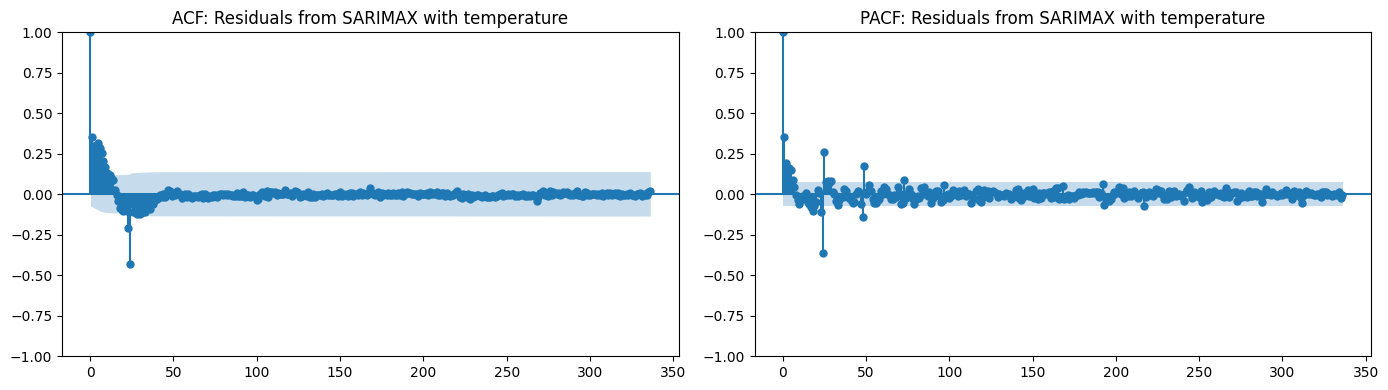

In [172]:
# --------------------------------------------------
# 6. Residual diagnostics
# --------------------------------------------------

resid = fit_2019.resid.dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(resid, lags=336, ax=axes[0])
axes[0].set_title("ACF: Residuals from SARIMAX with temperature")

plot_pacf(resid, lags=336, ax=axes[1], method="ywm")
axes[1].set_title("PACF: Residuals from SARIMAX with temperature")

plt.tight_layout()
plt.show()

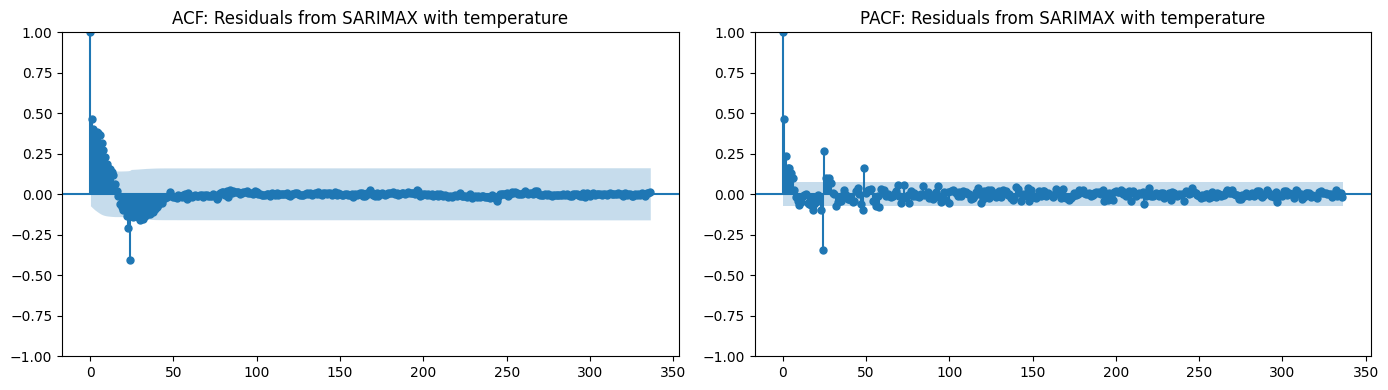

In [173]:
resid = fit_2020.resid.dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(resid, lags=336, ax=axes[0])
axes[0].set_title("ACF: Residuals from SARIMAX with temperature")

plot_pacf(resid, lags=336, ax=axes[1], method="ywm")
axes[1].set_title("PACF: Residuals from SARIMAX with temperature")

plt.tight_layout()
plt.show()

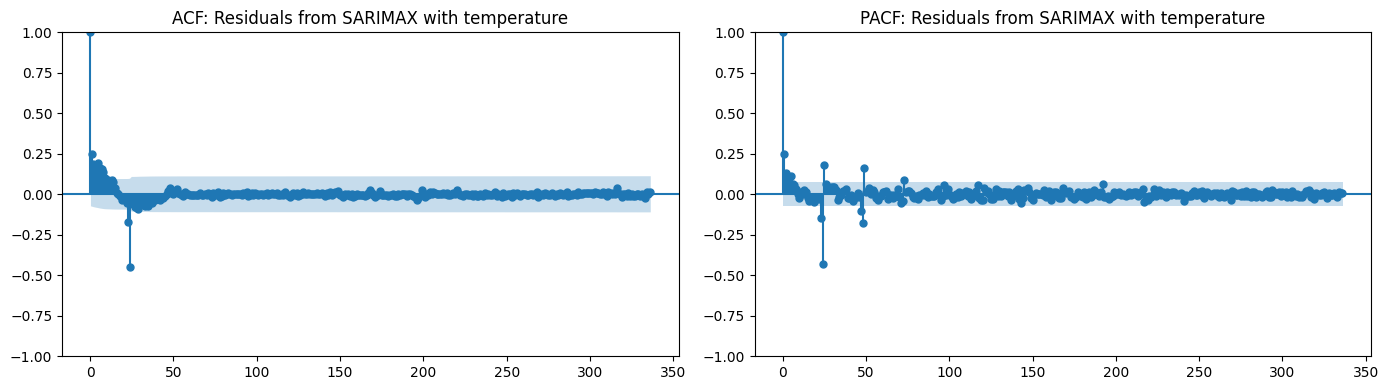

In [174]:
resid = fit_2021.resid.dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(resid, lags=336, ax=axes[0])
axes[0].set_title("ACF: Residuals from SARIMAX with temperature")

plot_pacf(resid, lags=336, ax=axes[1], method="ywm")
axes[1].set_title("PACF: Residuals from SARIMAX with temperature")

plt.tight_layout()
plt.show()

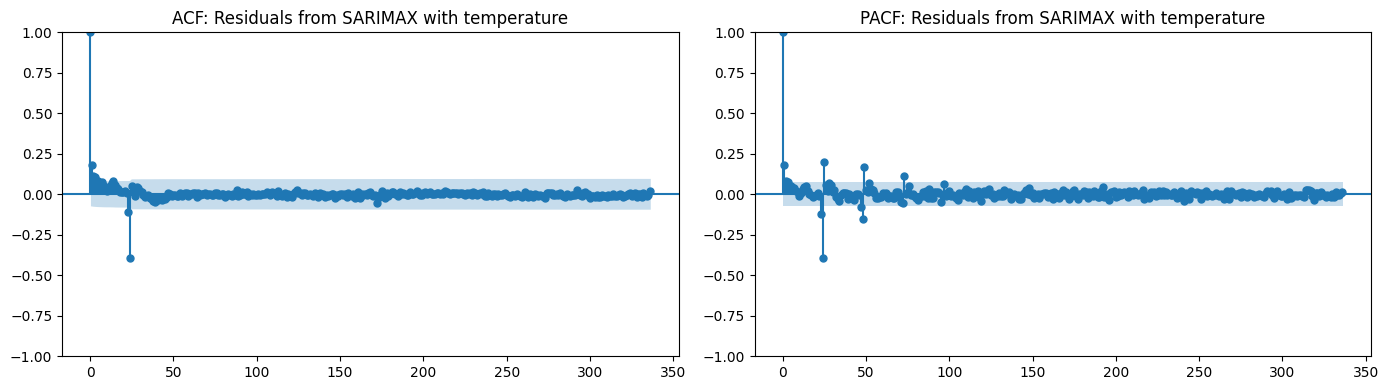

In [175]:
resid = fit_2022.resid.dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(resid, lags=336, ax=axes[0])
axes[0].set_title("ACF: Residuals from SARIMAX with temperature")

plot_pacf(resid, lags=336, ax=axes[1], method="ywm")
axes[1].set_title("PACF: Residuals from SARIMAX with temperature")

plt.tight_layout()
plt.show()

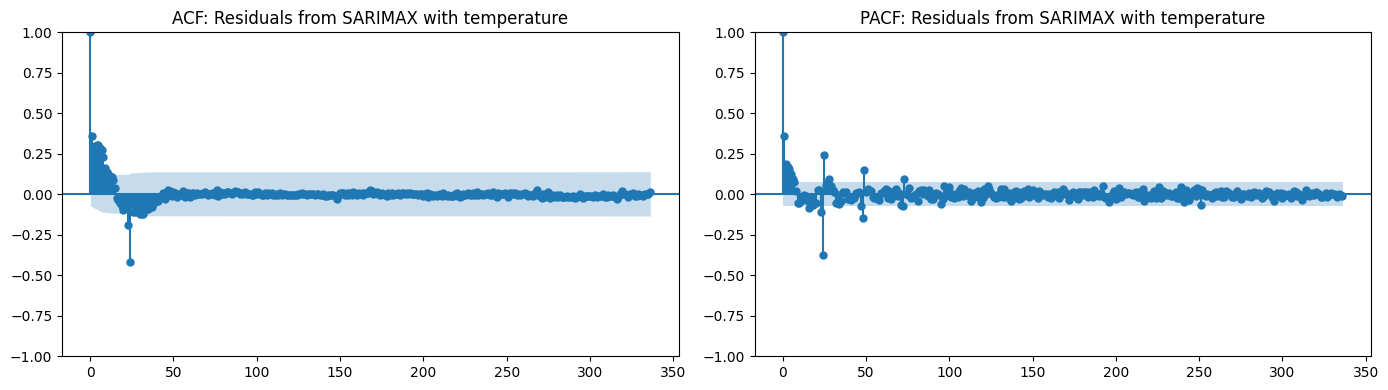

In [176]:
resid = fit_2023.resid.dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(resid, lags=336, ax=axes[0])
axes[0].set_title("ACF: Residuals from SARIMAX with temperature")

plot_pacf(resid, lags=336, ax=axes[1], method="ywm")
axes[1].set_title("PACF: Residuals from SARIMAX with temperature")

plt.tight_layout()
plt.show()

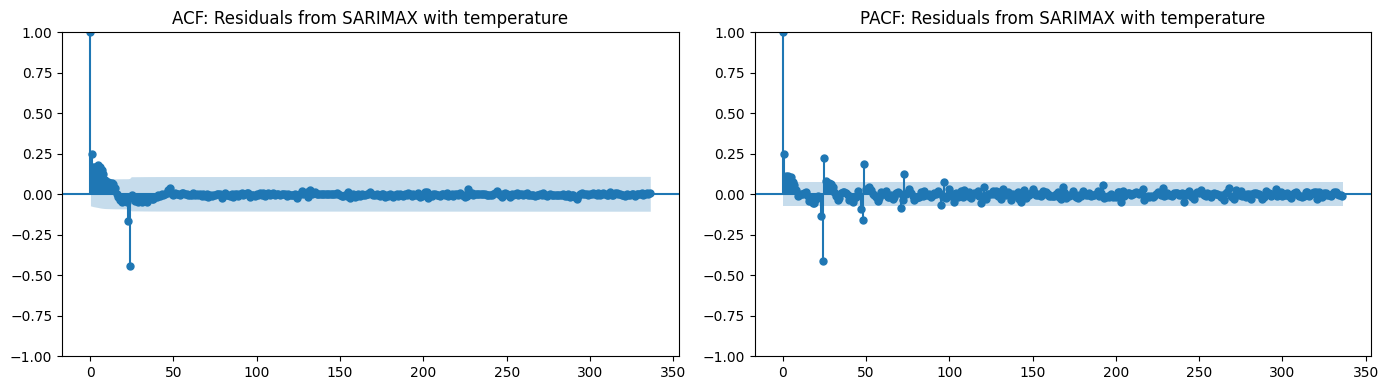

In [177]:
resid = fit_2024.resid.dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(resid, lags=336, ax=axes[0])
axes[0].set_title("ACF: Residuals from SARIMAX with temperature")

plot_pacf(resid, lags=336, ax=axes[1], method="ywm")
axes[1].set_title("PACF: Residuals from SARIMAX with temperature")

plt.tight_layout()
plt.show()

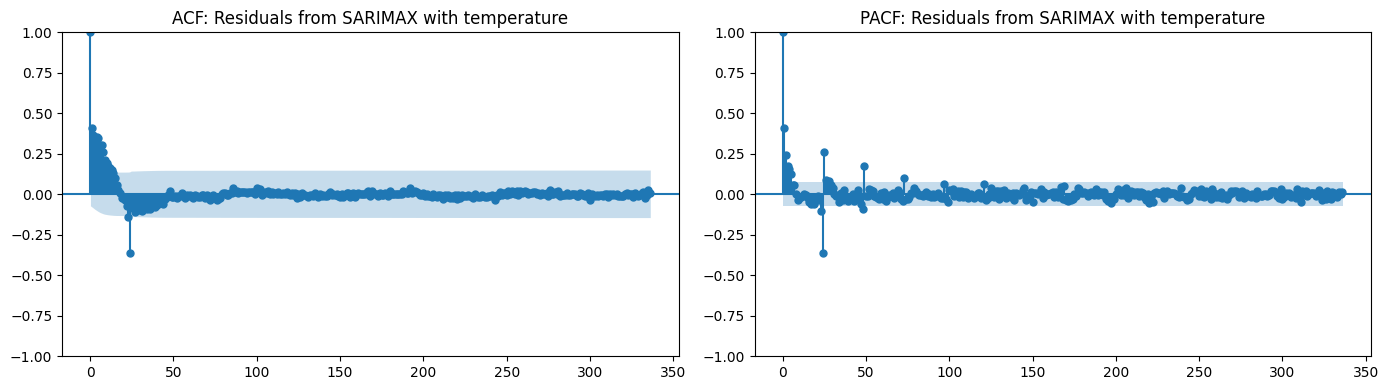

In [178]:
resid = fit_2025.resid.dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(resid, lags=336, ax=axes[0])
axes[0].set_title("ACF: Residuals from SARIMAX with temperature")

plot_pacf(resid, lags=336, ax=axes[1], method="ywm")
axes[1].set_title("PACF: Residuals from SARIMAX with temperature")

plt.tight_layout()
plt.show()

    year      feature      coef   std_err    pvalue     ci_low   ci_high  \
0   2019  temperature  0.444920  1.119683  0.691100  -1.749618  2.639459   
1   2019   wind_speed -0.173527  0.256615  0.498905  -0.676483  0.329430   
2   2020  temperature -1.739975  1.145350  0.128721  -3.984820  0.504871   
3   2020   wind_speed -0.145927  0.285867  0.609721  -0.706216  0.414362   
4   2021  temperature -1.308193  1.576414  0.406622  -4.397907  1.781522   
5   2021   wind_speed -0.185148  0.439948  0.673871  -1.047430  0.677134   
6   2022  temperature -0.303082  1.012321  0.764640  -2.287196  1.681031   
7   2022   wind_speed -0.020068  0.293331  0.945455  -0.594987  0.554851   
8   2023  temperature -0.730780  1.062128  0.491432  -2.812512  1.350953   
9   2023   wind_speed  0.040305  0.327663  0.902100  -0.601902  0.682512   
10  2024  temperature -1.534616  0.892920  0.085678  -3.284708  0.215476   
11  2024   wind_speed -0.584280  0.335331  0.081439  -1.241516  0.072956   
12  2025  te

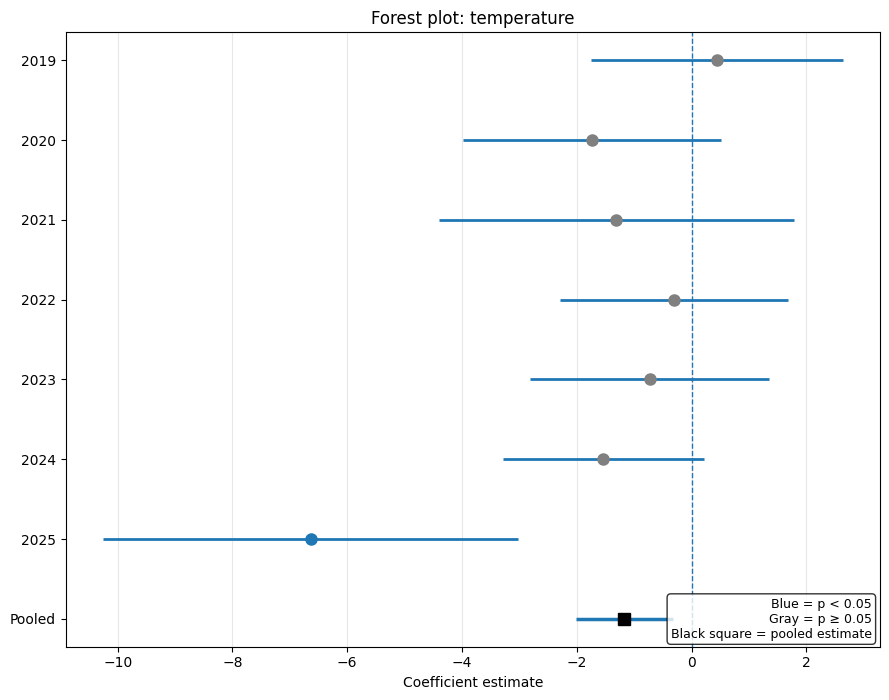

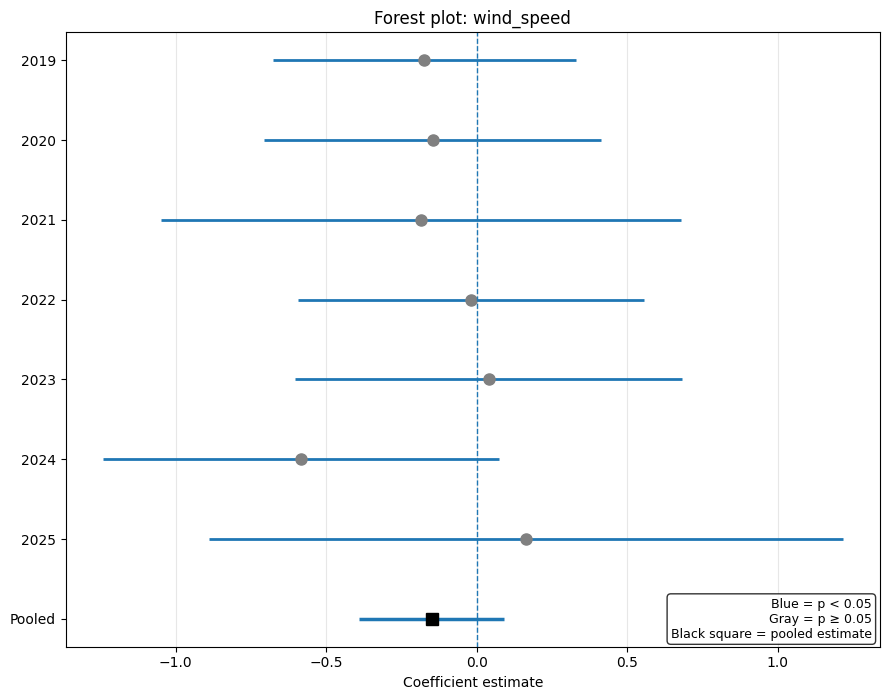

In [181]:
import os

def plot_forest_per_feature(coef_df, save_dir=None, show_pooled=True):
    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

    features = coef_df["feature"].unique()

    for feature in features:
        df_f = coef_df[coef_df["feature"] == feature].copy()
        df_f = df_f.sort_values("year")

        years = df_f["year"].astype(str).tolist()
        y_pos = np.arange(len(df_f))[::-1]  # top to bottom

        fig, ax = plt.subplots(figsize=(9, 5 + 0.3 * len(df_f)))

        # Plot confidence intervals and points
        for i, (_, row) in enumerate(df_f.iterrows()):
            ypos = y_pos[i]
            color = "tab:blue" if row["significant"] else "gray"

            ax.hlines(
                y=ypos,
                xmin=row["ci_low"],
                xmax=row["ci_high"],
                linewidth=2
            )
            ax.plot(
                row["coef"],
                ypos,
                "o",
                markersize=8,
                color=color
            )

        labels = years.copy()
        tick_positions = list(y_pos)

        # Optional pooled estimate
        if show_pooled and len(df_f) > 0:
            weights = 1 / (df_f["std_err"] ** 2)
            pooled_coef = np.sum(weights * df_f["coef"]) / np.sum(weights)
            pooled_se = np.sqrt(1 / np.sum(weights))
            pooled_low = pooled_coef - 1.96 * pooled_se
            pooled_high = pooled_coef + 1.96 * pooled_se

            pooled_y = -1
            ax.hlines(
                y=pooled_y,
                xmin=pooled_low,
                xmax=pooled_high,
                linewidth=2.5
            )
            ax.plot(
                pooled_coef,
                pooled_y,
                "s",
                markersize=9,
                color="black"
            )

            labels.append("Pooled")
            tick_positions.append(pooled_y)

        ax.axvline(0, linestyle="--", linewidth=1)

        ax.set_yticks(tick_positions)
        ax.set_yticklabels(labels)
        ax.set_xlabel("Coefficient estimate")
        ax.set_title(f"Forest plot: {feature}")
        ax.grid(True, axis="x", alpha=0.3)

        # Legend-like text
        ax.text(
            0.99, 0.01,
            "Blue = p < 0.05\nGray = p ≥ 0.05\nBlack square = pooled estimate",
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=9,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
        )

        plt.tight_layout()

        if save_dir is not None:
            filename = os.path.join(save_dir, f"forest_{feature}.png")
            plt.savefig(filename, dpi=150, bbox_inches="tight")

        plt.show()

def collect_feature_results(fits, features):
    rows = []

    for year, fit in fits.items():
        params = fit.params
        bse = fit.bse
        pvals = fit.pvalues
        ci = fit.conf_int()

        for feature in features:
            if feature in params.index:
                rows.append({
                    "year": year,
                    "feature": feature,
                    "coef": params[feature],
                    "std_err": bse[feature],
                    "pvalue": pvals[feature],
                    "ci_low": ci.loc[feature, 0],
                    "ci_high": ci.loc[feature, 1],
                    "significant": pvals[feature] < 0.05
                })

    df = pd.DataFrame(rows)
    return df


fits = {
    2019: fit_2019,
    2020: fit_2020,
    2021: fit_2021,
    2022: fit_2022,
    2023: fit_2023,
    2024: fit_2024,
    2025: fit_2025,
}

features_of_interest = [
    "temperature",
    "wind_speed",
    # "heating_degree",
    # "heating_degree_roll24",
    # "cold_wind",
]

coef_df = collect_feature_results(fits, features_of_interest)
print(coef_df)

plot_forest_per_feature(coef_df, save_dir="forest_plots", show_pooled=True)